# The paper's figures

Every figure in [arXiv:1904.12391](https://arxiv.org/abs/1904.12391) is produced here, and only here.

The plotting style is the group's standard `matplotlibrc`, inlined into the setup cell below rather than shipped as a separate file, with its sizes set for figures included at the paper's `\columnwidth`.

Running this notebook writes all fourteen PDFs. Set `NUOSC_PAPER_FIGDIR` to write them straight into the paper's directory.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Which codes these comparisons measured

Every external code is pinned. A version recorded as a month --- which
is how three of them were once recorded --- cannot be rebuilt, so each
entry below is a commit or a tarball hash, verified on
2026-08-07 to be the latest *official* release rather than merely
the version that happened to be installed.

| Code | Release | Pinned at | Where from |
|---|---|---|---|
| NuOscProbExact | stamped at run time | _this repository_ | -- |
| NuFast-LBL | tag `v2.0.1` | `a6eec95b3284` | [source](https://github.com/PeterDenton/NuFast.git) |
| NuFast-Earth | tag `v1.2.0` | `499392d49f21` | [source](https://github.com/PeterDenton/NuFast-Earth.git) |
| nuSQuIDS | tag `v1.13.3` | `104914da5a25` | [source](https://github.com/arguelles/nuSQuIDS.git) |
| nuCraft | r22 | sha256 `f406750025f8` | [source](https://nucraft.hepforge.org/nuCraft-r22.tar.gz) |
| GLoBES | 3.2.18 | sha256 `7edd0fea6780` | [source](https://www.mpi-hd.mpg.de/personalhomes/globes/download/globes-3.2.18.tar.gz) |
| Prob3++ | tag `v3r20` | `fa103b1e57fb` | [source](https://github.com/rogerwendell/prob3plusplus.git) |

### How they are built

Two profiles, because one flag set cannot serve both axes:

- **speed** --- each project's own upstream flags, so no code is ever
  published slower than its authors publish it.
- **accuracy** --- `-O3 -std=c++17` for everyone, no `-Ofast` and no
  `-ffast-math`, because value-changing flags make an accuracy
  measurement measure the flag instead of the code.

Threads are whatever each code naturally uses; none is forced to one,
and the effective count is recorded per run, so a cross-code speed
claim always carries both numbers.

One exception, recorded rather than hidden: **nuSQuIDS** is measured as
distributed, from its upstream wheel with GSL, HDF5 and SQuIDS bundled,
so its flags are the wheel's and the two-profile rule cannot apply.

`tests/bench/build.sh` clones, hash-verifies and builds all of it and
writes a build record with the compiler, the CPU and the manifest hash.
`tests/bench/OBJECTIONS.md` records what each measurement answers.

### Exactly which script produces each code's timings

One row per script, so a number in a figure can be traced to the file
that made it. A script recorded as `MISSING` was never committed ---
which is itself the reason this table exists.

| Code | Script run | What it writes | Figure |
|---|---|---|---|
| NuOscProbExact | `tests/prem_scan.py` | `tests/prem_speed_accuracy.json (3+1 panel ONLY; the three-flavor panel now comes from tests/bench/earth_plane.json)` | Fig. 11, 3+1 panel |
| NuOscProbExact | `tests/external_drivers/const_scan.py` | `tests/const_density_scan.json` | Fig. 9 (constant density), accuracy |
| NuOscProbExact | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| NuFast-LBL | `tests/bench/run_all.py (throughput cells) -> --join` | `tests/timing_other_codes.json` | Fig. 8, throughput vs stack size |
| NuFast-LBL | `MISSING -- driver not in the repository` | `tests/nufast_scan.json` | Fig. 9 accuracy; to be replaced by an adapter |
| NuFast-LBL | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| NuFast-Earth | `tests/external_drivers/nufast_drv.cpp` | `tests/external_drivers/nufast_earth_prem.txt` | Fig. 11, Earth speed + accuracy |
| NuFast-Earth | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| nuSQuIDS | `tests/bench/run_all.py (throughput cells) -> --join` | `tests/timing_other_codes.json` | Fig. 8, throughput vs stack size |
| nuSQuIDS | `tests/prem_scan.py` | `tests/prem_speed_accuracy.json (3+1 panel ONLY; the three-flavor panel now comes from tests/bench/earth_plane.json)` | Fig. 11, 3+1 panel |
| nuSQuIDS | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| nuCraft | `tests/prem_scan.py` | `tests/prem_speed_accuracy.json (3+1 panel ONLY; the three-flavor panel now comes from tests/bench/earth_plane.json)` | Fig. 11, 3+1 panel |
| nuCraft | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| GLoBES | `tests/bench/run_all.py (throughput cells) -> --join` | `tests/timing_other_codes.json` | Fig. 8, throughput vs stack size |
| GLoBES | `tests/external_drivers/globes_scan.c` | `constant-density accuracy scan` | Fig. 9 |
| GLoBES | `tests/external_drivers/globes_drv.c` | `tests/external_drivers/globes_prem.txt` | Fig. 11, Earth |
| GLoBES | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |
| Prob3++ | `tests/bench/run_all.py (throughput cells) -> --join` | `tests/timing_other_codes.json` | Fig. 8, throughput vs stack size |
| Prob3++ | `tests/external_drivers/prob3_scan.cpp` | `constant-density accuracy scan` | Fig. 9 |
| Prob3++ | `tests/external_drivers/prob3_drv.cpp` | `tests/external_drivers/prob3_prem.txt` | Fig. 11, Earth |
| Prob3++ | `tests/bench/run_all.py then --join` | `tests/bench/speed_accuracy_plane.json, tests/speed_accuracy.json, tests/bench/earth_plane.json` | Figs. 8, 10 and 11 (three flavors) |

These are the drivers the pipeline in `tests/bench/` replaces with
adapters, so that one harness owns every clock and no driver can time
itself.

## Each code is handed its own problem, and judged against its own reference

Comparing a code against a reference says something about its
propagation only if the two agree on what a kilometre is and what the
matter potential is. They do not agree natively: each code carries its
own rounding of $2\sqrt{2} G_F N_A$ and its own $\hbar c$.

An earlier version of this comparison rescaled every code's density
and baseline so that all of them reproduced *our* potential and *our*
kilometre, and then differenced them against one shared reference.
That made this library the only code receiving the problem it was
designed for, and it capped the whole figure at the size of the
largest deliberate mismatch. It is not what is done here.

Instead each code is handed honest physical inputs --- the density in
g cm$^{-3}$, the baseline in km, the same mixing parameters --- and is
differenced against a reference built in **its own** convention, using
the constants below and the profile it was actually given. The
residual then measures how well that code solves the problem it was
handed, which is the same kind of quantity for every code and is why
they may share one axes. Every caption has to say that the reference
differs per code.

| Code | Its matter constant | Its $\hbar c$ / eV m | Read from |
|---|---|---|---|
| NuFast-LBL | `0.000152588` | 1.97327e-07 | `NuFast_LBL.cpp` |
| NuFast-Earth | `0.0001526493231029146` | 1.97327e-07 | `Oscillation.cpp` |
| Prob3++ | `0.000152588` | 1.97316496e-07 | `mosc.c` |
| GLoBES | `7.63247e-14` | 1.97327e-07 | `glb_probability.h` |
| nuCraft | `0.00015256` | 1.9732693e-07 | `NuCraft.py` |

NuFast-LBL and Prob3++ share a matter constant because they genuinely
carry the same rounding, `1.52588e-4` --- a coincidence that once
looked like a bug in our own bookkeeping and was not. The two NuFast
codes, by contrast, do *not* share one: they differ in the fifth digit,
so a reference built for one is wrong for the other.

$\hbar c$ is where the codes are least alike. Three of them agree on
$1.97327 \times 10^{-7}$ eV m. Prob3++ does not: it hard-codes the
combination as `2.534` in `mosc.c`, four significant figures, implying
$1.9731650 \times 10^{-7}$. That is a relative difference of
$5 \times 10^{-5}$ in every length, and while a single shared cosine
scale was applied to all three it left exactly that error in place for
Prob3++ alone, where it showed up as an accuracy floor near
$3 \times 10^{-4}$ that had nothing to do with the algorithm. Each
code now gets its own value, read from its own source.

### One parameter set, converted rather than retyped

Every code is handed the same physics: $\sin^2\theta_{12} = 0.31$,
$\sin^2\theta_{13} = 0.0224$, $\sin^2\theta_{23} = 0.582$,
$\delta_{\rm CP} = 217^\circ$, $\Delta m^2_{21} = 7.39e-05$ eV$^2$,
$\Delta m^2_{31} = 0.002525$ eV$^2$, normal ordering.

The mixing parameters are the one thing that is *shared* rather than
per code, and each reference is built with the same set. Where a code
wants a different *parameterisation* of that same physics, the
conversion is derived and the reference is built from the very number
the code received. Prob3++ takes $\Delta m^2_{32}$, so it is handed
`2.4511000e-03` eV$^2$, which is $\Delta m^2_{31} - \Delta m^2_{21}$
rather than a second number typed by hand; nuCraft takes angles, so it
is handed $\arcsin\sqrt{\sin^2\theta}$. A hand-typed `2.4511e-3`
sitting beside a `2.525e-3` is indistinguishable from a physics
difference, which is why neither is typed.

### The one convention that is deliberately not absorbed

nuCraft's charged-current and sterile matter entries are two
independently rounded constants, `0.00015256` and `7.6525e-05`, whose ratio is
$0.50161$ where the isoscalar value is exactly $1/2$.
That is an error rather than a convention, so its reference uses
nuCraft's constants for the units but the correct ratio. A reference
that absorbed the rounding too would forgive the defect and the floor
it causes would silently vanish. It bites only at four flavors: at
three the sterile entry never enters.

Because no convention mismatch is left anywhere else, no figure here
has a floor that is an artifact of one. Each code can reach round-off
if its algorithm can, which is what makes the reference's own
precision the thing that has to be argued rather than assumed.

## How good each reference is, and what it had to match

Each code is differenced against its own 50-digit reference, so the
reference has to solve the problem that code was handed and not a
neighbouring one. That means matching, per code, the matter
constant, $\hbar c$, the electron fraction, the chord, and --- the
one that turned out to be hardest --- the discretised profile.

Every number below is measured by
`tests/bench/audit_reference.py` and read from the artifact it
writes, at $\cos\theta_z = -0.9$ and $E = 10$ GeV with $Y_e = 0.5$,
at 50 working digits.

| Code | Matter constant | km / eV$^{-1}$ | Profile it is handed | Profile match | Reference error |
|---|---|---|---|---|---|
| {\tt NuOscProbExact} | 1.514422964e-04 | 5067730000.00 | the continuous PREM | built identically | 2e-18 |
| {\tt NuFast-LBL} | 1.525880000e-04 | 5067730214.31 | none -- constant density only | built identically | 1e-45 |
| {\tt NuFast-Earth} | 1.526493231e-04 | 5067730214.31 | four major PREM layers, each cut into n uniform sub-shells held at their midpoint density | built identically | 1e-45 |
| {\tt Prob3++} | 1.525880000e-04 | 5068000000.00 | the same uniform sub-shells, through a profile file | built identically | 1e-45 |
| {\tt GLoBES} | 1.526494000e-04 | 5067730214.31 | the same uniform sub-shells, chord-decomposed | built identically | 1e-45 |
| {\tt nuSQuIDS} | 1.526493245e-04 | 5067730716.16 | an Akima spline that EarthAtm builds itself over the nodes it is handed | 5.3e-15 | 5e-14 |
| {\tt nuCraft} | 1.525600000e-04 | 5067732000.00 | a k=1 spline, the object the adapter hands it | exact | 2e-13 |

$Y_e$ is shared by every code and every reference, and so are the
mixing parameters; everything else in that table is per code.

### Why the errors differ by thirty-five orders of magnitude

The three compiled Earth codes are handed a stack of uniform
shells. A stack of uniform shells has an exact answer --- a finite
product of matrix exponentials --- so their references carry no
discretisation error at all and are limited only by the arithmetic.
The same is true of every constant-density reference, which is one
exponential. Those are the entries near $10^{-45}$.

The remaining codes are handed a profile that varies continuously,
so their references are slab products extrapolated to zero slab
width. That extrapolation is where the work is, and it failed twice
before it worked.

### Which Earth each reference is built on

There is one physical Earth --- the continuous PREM, whose density
varies smoothly inside each shell --- and every reference here is
built on it. Each code is then scored by how far its answer sits from
that Earth, in its own $\hbar c$ and its own matter normalisation,
with the same $Y_e$ and the same mixing parameters as every other.

Most of these codes cannot represent that Earth. Only three see a
density that varies inside an interval at all:

| Code | Density inside an interval | Set by |
|---|---|---|
| {\tt NuOscProbExact} | varies --- PREM polynomial | the physics |
| {\tt nuSQuIDS} | varies --- Akima spline | the code itself |
| {\tt nuCraft} | varies --- linear spline | its own interpolator type |
| {\tt Prob3++} | constant per layer | its interface takes (radius, density) rows |
| {\tt GLoBES} | constant per layer | its interface takes (length, density) pairs |
| {\tt NuFast-Earth} | constant per slab | its geometry makes one slab per declared discontinuity |

NuFast-Earth is worth stating precisely, because its interface
suggests otherwise. It accepts an arbitrary density callback, which
reads like an invitation to hand it the continuous profile, and it
carries a flag named as though it selected between constant and
varying shells. It does not. The engine always builds piecewise
constant slabs, one per interval between the discontinuities it is
given; the flag chooses only whether each slab carries the midpoint
density or the mean over its interval. There is no mode in which the
density varies inside a slab.

That distinction is not academic. Handing it the nine PREM boundaries
and the varying-shell flag --- which looks like asking for continuous
treatment --- gives ten slabs for the whole chord and an error of
$3 \times 10^{-2}$, five orders worse than the fine discretisation
it replaced. The discretisation is set by the discontinuity list, not
by the flag.

So three of these codes must discretise the Earth to compute at all,
and their distance from the true PREM is a real error a user pays
rather than an artifact of how they are scored. Measured on one chord,
at 1024 slabs for the compiled codes and 256 slabs per segment for
this library, all four land in the same place: about
$4 \times 10^{-7}$. That is the discretisation they share, not a
property of any one of them.

### The alternative, and why it was rejected

The other option was to score each code against a reference built on
its own discretised profile --- the shell stack it was actually
handed. Measured, that puts Prob3++ and GLoBES at $10^{-13}$ while
this library, which cuts the continuous profile itself, sits at
$4 \times 10^{-7}$: an apparent six-order advantage that is entirely
an artifact of a reference sharing its code's approximation.

Applied consistently that basis is not unfair --- every code lands at
round-off --- but it is empty. It measures whether a code evaluates
its own discretisation self-consistently, which they all do, and it
says nothing about which code is closer to the Earth. It also makes
every discretisation dial flat by construction, since the reference
moves with the dial. The continuous basis keeps those dials
meaningful, and convergence toward the true profile is what the
accuracy figure is for.

### One code needs two configurations

NuFast-Earth caches its eigenvalues across zenith angles when its
slabs carry midpoint densities, and that caching is the whole subject
of one of the objections raised against the earlier comparison: on an
oscillogram grid it is worth roughly a factor of eight per
probability. Asking instead for mean densities defeats it --- the
engine then computes one eigendecomposition per energy, zenith and
layer rather than one per energy and shell reused across every zenith.

Neither configuration is uniformly more accurate. Measured on one
chord at three energies, the mean-density slabs are better at two of
them --- $3.7 \times 10^{-7}$ against $4.1 \times 10^{-7}$, and
$2.7 \times 10^{-8}$ against $3.6 \times 10^{-7}$ --- and about
three times worse at the third, $3.0 \times 10^{-8}$ against
$8.8 \times 10^{-9}$. Three points do not establish a winner and
this text will not claim one; both sit in the same
$10^{-8}$ to $10^{-7}$ band, which is the discretisation they share.

The reason both are recorded is therefore the caching, not the
accuracy. The speed axis uses the midpoint configuration because that
is where the code's zenith caching lives and running it otherwise
would measure it below its best. The accuracy axis uses whichever is
stated on the series. Both are legitimate ways to run the code and
neither is a handicap, but they are different configurations and no
figure may put them on one axes.

### Two things that limited it, neither of them obvious

The first was **arithmetic**. In double precision the extrapolated
slab product floors near $2 \times 10^{-12}$: the first Richardson
pass converges cleanly at fourth order, but a second pass gains
nothing, because by then the error is accumulated round-off over the
ten thousand matrix products rather than discretisation. No amount
of extrapolation gets past that, which is why the references are
built in arbitrary precision.

The second was **geometry**. With the arithmetic fixed, the
extrapolation still stalled near $10^{-17}$. Extrapolating the slab
count to infinity is a statement about the continuous profile, so
the chord crossing radii are part of the answer rather than an input
to it, and their double-precision representation error breaks the
smooth expansion the extrapolation assumes. Computing the chord in
arbitrary precision too --- the total path length then matches
$-2R\cos\theta_z$ to twenty-two digits --- removed it.

### A third, and the two faults that were hiding each other

Two codes are handed a *spline* rather than a stack of shells:
nuCraft gets a linear one, and nuSQuIDS builds an Akima spline
inside its own Earth model. Their references appeared to stall eight
orders short, near $5 \times 10^{-10}$, with everything else
already correct. Two separate things were wrong, and each concealed
the other; the sequence is worth setting out, because the first
repair looked like a failure and was not.

The first fault was real. A spline is only piecewise smooth: its
density has a kink at every knot, and a slab that straddles a kink
sees a profile with no convergent expansion in the slab width, so
the extrapolation has nothing to extrapolate. The repair is the rule
the library already applies to PREM boundaries, which are mandatory
slab edges for exactly this reason --- every spline knot became a
mandatory slab edge too, putting each slab inside a single
polynomial piece.

That repair appeared to accomplish almost nothing. The quoted error
moved from $5.8 \times 10^{-10}$ to $3.3 \times 10^{-10}$ for
nuCraft, a factor of under two, and the natural reading was that the
kinks had never been the problem.

The natural reading was wrong, and what established it was printing
the whole extrapolation table instead of the single number at its
corner. Every level of that table falls by exactly the factor it
should --- 4, then 16, then 64 --- which is what a smooth expansion
looks like and is not what a straddled kink produces. Measured
against the value now established, the pre-repair corner was
$9.6 \times 10^{-10}$ from the truth and the post-repair corner is
$1.9 \times 10^{-13}$: the kink repair bought three orders, not a
factor of two.

The second fault was the *error estimate*, and it was hiding the
first. The estimate is the standard Romberg one --- how far the
corner moves when the last rung of the ladder is added --- which
bounds the error of the corner one level shallower. That is
conservative and correct, but only informative when the shallower
corner is itself good. With a four-rung ladder the shallower corner
sits two extrapolation levels back, and its error was
$3 \times 10^{-10}$ while the returned corner was already at
$2 \times 10^{-13}$. The number being quoted was never the
reference's error. It was the error of a corner that had been
computed and discarded, and it overstated the truth by a factor of
about seventeen hundred. A fifth rung moves the comparison one level
deeper and the quoted figure becomes the measured
$2 \times 10^{-13}$ and $5 \times 10^{-14}$.

This is worth recording because of how it would have failed. The
profiles themselves were right the whole time --- the audit measures
nuCraft's as exact, since the adapter hands it the very spline
object the reference uses, and nuSQuIDS' as agreeing to double
round-off --- so every check aimed at *whether the reference matches
the code* passed, correctly. What was wrong sat on top of a correct
profile, and its residual would have been read as those two codes'
solver error. The general lesson is narrower than "check your work":
a single summary number can be wrong in a way the quantity it
summarises is not, and the table it came from is what says so.

### The Akima variant, which is not a detail

nuSQuIDS does not accept a profile; it accepts nodes and builds its
own Akima spline over them. Substituting a different library's
Akima looks harmless and is not: the two agree *exactly* at the data
nodes and differ by about $2 \times 10^{-8}$ between them, which put
a relative error near $10^{-9}$ into the profile --- three orders
above the tight end of nuSQuIDS' own tolerance dial, and shaped
exactly like solver error. Its own construction is reproduced
instead, and the reference profile now agrees with what nuSQuIDS
reports along the chord to double round-off.

The general point is the one the whole per-code reference scheme
rests on: a reference that is subtly wrong does not announce itself.
It produces a residual of a plausible size, and that residual gets
read as the code's accuracy.

## Exactly how each code was driven

A speed or accuracy number is only checkable if the configuration
that produced it is written down. Everything in this section is what
the benchmark actually did: the pins and flags are read from the
manifest the build script consumes, and the configuration choices are
stated so that a reader who disagrees with one can see precisely what
to change.

Two rules were applied throughout. Each code is built with **its own
upstream flags** for the speed axis, so no code is published slower
than its authors publish it. Each is driven through **its own batched
entry point** where it has one, and looped in its own language where
it does not --- a loop that its interface requires is not a handicap
imposed from outside, and it is labelled as a loop.

### Build profiles

Two, because one flag set cannot serve both axes. The speed profile
uses each project's own flags. The accuracy profile uses
`-O3 -std=c++17` with no `-Ofast` and no `-ffast-math`, because a
value-changing flag makes an accuracy measurement measure the flag.
The previous generation of this comparison used `-Ofast -ffast-math`
for one dataset and `-O3` for another and presented them as one
methodology.

| Code | Pin | Speed flags | Flags from |
|---|---|---|---|
| {\tt NuFast-LBL} | tag `v2.0.1`, commit `a6eec95b3284` | `-Ofast -ffast-math -std=c++17` | Benchmarks/Makefile and compile.sh, upstream |
| {\tt NuFast-Earth} | tag `v1.2.0`, commit `499392d49f21` | `-O3 -std=c++17` | upstream Makefile (CFlags) |
| {\tt Prob3++} | tag `v3r20`, commit `fa103b1e57fb` | `-O2` | -- |
| {\tt GLoBES} | version `3.2.18`, sha256 `7edd0fea6780` | `-O2` | upstream configure default |
| {\tt nuSQuIDS} | tag `v1.13.3`, commit `104914da5a25` | `upstream configure defaults` | -- |
| {\tt nuCraft} | version `r22`, sha256 `f406750025f8` | `n/a` | -- |

### {\tt NuFast-LBL}

Driven through `Probability_Matter_LBL`, the one batched entry point
in the release: it takes the whole energy vector by const reference
and fills a vector of 3x3 matrices, so `evaluate` makes exactly one
call however many energies the grid holds. The author's own
benchmark harness calls it the same way. There is no persistent
engine, so nothing can be cached between calls and the per-call setup
cost is paid inside the timed region, where the code itself pays it.

The released source ships no header and carries its own demo
`main()`, so the object is compiled with `-Dmain=` renaming that
entry point --- otherwise it collides with the harness's `main` and
the translation unit will not link.

Precision knob: `N_Newton`, swept over `{-1, 0, 1, 2, 3}`. The negative value
is not a sentinel for "off": it selects exact eigenvalues through the
trigonometric root rather than Newton refinement. It was absent from
the earlier comparison, which is what made the claim that no code was
more accurate "at any setting it exposes" false.

### {\tt NuFast-Earth}

Driven through `Set_Spectra` followed by `Get_Probabilities`, which
batches over energy **and** zenith angle together and returns the
whole grid from one call. Everything invariant under a $\delta_{\rm
CP}$ scan is built once before any clock starts: the Earth model, the
engine, the profile, the production height, the eigenvalue precision,
and both spectra. The scan moves `Set_delta` alone.

The Earth model handed to it is this library's PREM, cut into four
major layers of 256 uniform sub-shells each --- 1024 in total ---
declared to the engine as its discontinuity list. That list *is* the
discretisation: the engine builds one slab per interval between
consecutive entries. Its electron fraction is the shared $Y_e = 1/2$,
not the 0.466/0.494 split its own `PREM_Full` carries, so that its
matter potential matches every other code's.

The detector depth is zero and the production height is zero, so the
trajectory is surface to surface, matching what the other Earth codes
are given.

Constant-density problems use `Set_E_Spectra` with `Set_Trajectory`
--- the single-trajectory mode added in v1.1.0 --- rather than a
chord. The two modes are mutually exclusive in the engine and the
choice is made once at setup. `Set_Production_Height` must not be
called in that mode; it asserts against it, and the constructor
already defaults the height to zero.

Precision knob: `eigenvalue_precision`, `n_layers`, swept over `{-1, 0, 1, 2, 3}` with the negative
value selecting exact eigenvalues.

### {\tt Prob3++}

Looped, one energy at a time, because that is the shape of its
interface: `SetMNS` takes the energy as an argument and `propagate`
takes no grid. The loop is in C++ inside the adapter's own
translation unit and the capability registry says the code does not
batch, so no reader can mistake the loop for a choice.

It is handed a profile file holding the same 1024 sub-shells the
other Earth codes receive, with rows of outer radius, density and
electron fraction. On the spherical path the electron fraction is
read from that file's $Y_p$ column rather than from
`SetDensityConversion`, which reaches only the linear path.
`propagate` re-derives the per-trajectory profile on every call by
its own design, and that cost is timed as part of the code.

`SetMNS` is called with squared-sine inputs and the neutrino type,
and takes $\Delta m^2_{32}$ rather than $\Delta m^2_{31}$ --- derived
from the shared parameters, never typed a second time. Warnings are
suppressed and the profile loader's announcement on standard output
is silenced for the one untimed constructor call, so that it cannot
land in front of the harness's JSON.

Its `mosc.c` and `mosc3.c` must be compiled as C rather than C++.
Precision knob: `n_shells`, the sub-shell count per major layer.

### {\tt GLoBES}

Looped, one energy at a time: `glb_probability_matrix` takes an
arbitrary layered profile and a single energy, and the library exposes
no batched alternative at that level. The filter is disabled by
passing a negative width, so the exact per-layer diagonalisation runs
rather than the low-pass approximation.

It is handed the chord decomposition of the same 1024 sub-shells,
computed once in setup and never inside a clock. GLoBES multiplies
the density it is given by its own `GLB_V_FACTOR` and its own
`GLB_Ne_MANTLE` internally, so the density handed over carries the
ratio of the shared $Y_e$ to that internal electron fraction --- and
nothing else. Its `GLB_V_FACTOR` is absorbed into its own reference
instead of being applied to its input.

The $\delta_{\rm CP}$ scan calls `glbSetOscParams` followed by
`glbSetOscillationParameters`, so the mixing-matrix rebuild is inside
the timed region, which is the cost the amortized protocol is defined
to include. Built once at the upstream configure default `-O2`: the
measured code lives in the installed library, so relinking the thin
adapter at other flags would not change what is being measured.
Precision knob: `n_shells`.

### {\tt nuSQuIDS}

Driven through the multiple-energy constructor, which is its batched
entry point, with interactions disabled. The body, the tracks, the
solver, every mixing angle and mass splitting and the tolerance are
all built in setup; the scan moves `Set_CPPhase` alone. Zenith is not
batched --- the constructor takes energies only --- so multiple angles
are looped, and the registry says so.

Two configuration points matter and neither is a default.

First, **the solver tolerance is always set explicitly**. Left at its
constructor defaults the GSL integrator fails outright on both Earth
grids used here, at $\cos\theta_z = -1$ and $-0.9$, while every
explicit tolerance from $10^{-6}$ to $10^{-10}$ succeeds. Leaving it
at "its own defaults" is therefore not a runnable configuration for
this comparison, and the knob's zero setting means an explicit
mid-sweep tolerance rather than whatever the constructor chose.

Second, **constant-density problems use its exact algebraic mode**.
With `Set_AllowConstantDensityOscillationOnlyEvolution`, the solver
skips the ODE entirely and evolves each energy node in closed form,
which is what a practised user of this code would do rather than
integrate through a constant. That mode is not an unqualified
improvement and the figure says so: it is exact at 59 of 60 nodes,
with a median error of $4 \times 10^{-16}$, but carries a
tolerance-independent excursion of $7 \times 10^{-7}$ between roughly
3.4 and 6.5 GeV, where the tight ODE reaches $3 \times 10^{-12}$
everywhere. Whichever produced a number, the series records it.

Probabilities are read out at the solver's own nodes rather than
through the interpolating overload, since the grid energies are those
nodes: the interpolating call would charge an interpolation inside the
timed region for nothing. The Earth model is built from a table
aligned on every PREM boundary, which nuSQuIDS interpolates with an
Akima spline of its own construction; the atmosphere height is set to
zero so the chord is surface to surface. Precision knob: `abs_error`, `rel_error`.

### {\tt nuCraft}

Its `CalcWeights` takes a particle list but loops over it internally,
so the registry records the batching as interface-only. The whole
(energy, zenith) grid is still handed over in one call, so that no
code here is looped from outside when its own interface would take the
stack.

There is no setter for the CP phase --- it rides on the mixing-angle
list given to the constructor --- so the scan rebuilds the instance
around a hoisted Earth model. That reconstruction is the cost this
interface charges a scan, and the amortized protocol is defined to
include it.

Mixing angles are passed in degrees, derived from the shared squared
sines rather than retyped. The profile is installed through the
model's interpolator, because its file route is Python 2 only, and
it is given the same object type the code builds for itself: a linear
spline over this library's PREM. Passing a plain Python callback
instead would put this library's scalar density lookup inside
nuCraft's integrator, which is our cost charged to its measurement.

Its own model dictionary carries an inner-core radius of 1121.5 km
against its own profile table, which steps at 1221.5; the adapter
overrides it with the boundary from this library's PREM. The
trajectory is surface to surface with the atmosphere mode that takes
the zenith angle in radians rather than its cosine. Constant-density
problems are refused rather than faked: this code propagates through
its Earth model only. Precision knob: `numPrec`.

### What is hoisted, for every code alike

The harness owns every clock; an adapter supplies physics and cannot
time anything. Before a scan is timed, each code has already built
its body or Earth model, constructed its engine, installed its
profile, allocated the grid and called every setter except the one the
scan moves. That contract is enforced rather than trusted, because the
previous generation of drivers put an engine construction, an Earth
object and five setters inside a timed loop over twelve energies.

## What is timed, and why each repetition starts afresh

Two protocols are reported, and they answer different questions. The
difference between them is not a detail of the harness: applied to one
of the codes it moves the number by about a factor of 6000, so which
one a figure reports has to be stated on the figure.

### The scan, with caching left standing

The first protocol times a scan over $\delta_{\rm CP}$: each step
sets the one parameter that moves and asks for the whole grid.
Everything invariant under that scan --- the Earth model, the engine,
the profile, the grid arrays, every other setter --- is built once
before the clock starts. Each code's own caching is left switched on
and working, so a code that can reuse eigenvalues across zenith angles
does reuse them here. This is the cost a fit or a scan actually pays,
and the definition is taken from the NuFast-Earth author's own
harness rather than invented for this comparison.

### One request, started afresh each time

The second protocol asks a different question: what does it cost to
ask for $N$ points once? A single such call is far too fast to put a
clock around, so it is repeated until the block is long enough to
measure. Those repetitions are a measuring device, not a workload ---
nobody asks the same question thousands of times against unchanged
state --- and the average is the cost of a request only if every
repetition costs what the first one cost.

So **every repetition starts afresh**, which is closer to what a user
does in practice: a person with a new question asks it from a standing
start, and does not inherit the intermediate results of the previous
one. Before each repetition the driver is returned to the state a
fresh request would find. What that means is drawn at the same line
for every code: the geometry and the profile were installed once and
stay installed, exactly as a user would not rebuild the Earth between
two questions about it, while everything that depends on the
oscillation parameters is computed again.

For six of the seven codes this changes nothing, because they already
recompute everything on every call --- their reset is empty, and
honestly so. The seventh, NuFast-Earth, caches its eigenvalues and its
internal amplitudes between calls. Left alone, its second and every
later repetition timed nothing but a rotation of amplitudes that an
earlier, untimed call had left lying around, and the reported cost per
point fell by about a factor of 6000 below what one request costs.
Published unchanged, that would have shown a throughput advantage of
four orders of magnitude which was very largely an artifact of how the
measurement was taken.

Making each repetition cold does not take that code's advantage away.
It is still several times faster than the other compiled codes on the
same grid, which is a claim that survives being looked at. And the
caching itself is not discarded from the comparison: it is exactly
what the first protocol measures, on its own author's definition, and
both numbers are reported. The gap between them *is* what the caching
buys.

Every timed series therefore carries which protocol produced it, and
series from the two protocols are never drawn on one axes.

In [2]:
# The artifacts every figure below is drawn from.
#
# These come from the rebuilt pipeline: tests/bench/sweep_accuracy.py for the
# accuracy axis and tests/bench/run_all.py for the timed axes.  The figures
# used to read six frozen files written before that pipeline existed, under a
# shared reference, with one code's Earth model mis-initialised and another's
# hbar c wrong.  Re-running the notebook would have faithfully reproduced
# those figures, which is the failure this cell exists to prevent: a missing
# artifact now raises rather than letting a stale one be plotted.
import json
import os

BENCH = os.path.join('..', 'tests', 'bench')


def artifact(name, what):
    """Loads a pipeline artifact, or says exactly how to produce it."""
    path = os.path.join(BENCH, name)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "%s is missing, so %s cannot be drawn from measured data.\n"
            "Produce it with:  %s\n"
            "The figures are deliberately NOT falling back to the pre-rebuild "
            "files: those were taken under a shared reference and with two "
            "codes misconfigured." % (path, what,
                                      'python tests/bench/sweep_accuracy.py'
                                      if name.startswith('accuracy')
                                      else 'python tests/bench/run_all.py'))
    with open(path) as handle:
        return json.load(handle)


#: Channel order in every accuracy artifact, from bench.hpp's contract.
NUE, NUMU, NUTAU = 0, 1, 2


def channel(record, code, knob, which):
    """Returns one channel of one code's series, as an array."""
    series = record['series'][code]['by_knob'][str(knob)]
    return np.array(series['probabilities'])[which::3]


ACC_CONST = artifact('accuracy_const.json', 'the constant-density accuracy figure')
print('accuracy artifacts loaded; basis =', ACC_CONST['profile_basis'],
      '| codes =', len(ACC_CONST['series']))

accuracy artifacts loaded; basis = continuous | codes = 7


In [3]:
import earth
import slabs
from scipy.linalg import expm
import json
import shutil
from matplotlib.patches import (Rectangle, FancyArrowPatch,
                                Wedge, Polygon, Circle)
import matplotlib.patheffects as pe

# The paper's figures are drawn at \columnwidth -- 229.5 pt = 3.184 in for its
# two-column elsarticle layout -- so that each PDF is included at 1:1 and the
# labels come out at the size they are set at here.
COLW = 229.5/72.27

# The group's standard matplotlibrc, inlined so that the paper's figures do not
# depend on a resource file outside this repository.  The style is unchanged --
# Palatino set through LaTeX, ticks inward on all four sides, framed legends
# with a black border, Type 42 fonts -- but the sizes, which that file chooses
# for standalone 5-inch figures, are set here for figures included at
# \columnwidth beside 10 pt body text.
#
# Setting the labels through LaTeX needs a TeX installation, and Palatino comes
# from that installation rather than from matplotlib.  A machine that only wants
# to check the notebook still runs -- CI, most obviously -- has no reason to
# carry one, so this asks rather than assumes.  With LaTeX the figures are
# exactly the paper's; without it the labels fall back to matplotlib's own
# mathtext, which changes how they are typeset and nothing about what is
# plotted.  Every construct these figures use, \mathbb included, renders under
# both.
HAVE_LATEX = shutil.which('latex') is not None

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino'],
    'text.usetex': HAVE_LATEX,
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.1,
    'xtick.top': True, 'xtick.bottom': True, 'xtick.direction': 'in',
    'ytick.left': True, 'ytick.right': True, 'ytick.direction': 'in',
    'xtick.major.size': 3.5, 'xtick.minor.size': 2.0,
    'ytick.major.size': 3.5, 'ytick.minor.size': 2.0,
    'xtick.major.width': 0.7, 'xtick.minor.width': 0.7,
    'ytick.major.width': 0.7, 'ytick.minor.width': 0.7,
    'xtick.major.pad': 3.0, 'ytick.major.pad': 3.0,
    'legend.frameon': True, 'legend.edgecolor': 'black',
    'legend.framealpha': 1.0, 'legend.fancybox': False,
    'legend.borderpad': 0.4, 'legend.handlelength': 1.9,
    'legend.handletextpad': 0.5, 'legend.columnspacing': 0.9,
    'legend.labelspacing': 0.35,
    # The shared setup cell above turns the grid on for the exploratory
    # notebooks; the paper's figures, like the group's matplotlibrc, leave
    # it off.
    'axes.grid': False,
    # Axes end exactly at the data in x.  y is left to autoscale: forcing 0-1
    # flattens the three-flavor panels, whose probabilities span a narrow range.
    'axes.xmargin': 0.0,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

if not HAVE_LATEX:
    # Palatino is supplied by the TeX installation, so asking for it without
    # one earns a missing-font warning per figure and DejaVu Serif anyway.
    plt.rcParams['font.serif'] = plt.rcParamsDefault['font.serif']
    print('latex not found: labels fall back to mathtext, and the serif face '
          'to matplotlib default.  The figures are the paper figures; the '
          'typesetting is not.')

# One-panel figures are square; the stacked ones keep the aspect the paper used.
FIGSIZE_SQUARE = (COLW, COLW)
FIGSIZE_STACK = (COLW, COLW*991.458/565.587)
STYLES = ['-', '--', ':', '-.']

def framed(ax, **kw):
    """A legend with a black frame at the weight of the axes spines."""
    leg = ax.legend(**kw)
    leg.get_frame().set_linewidth(0.7)
    return leg

# Set NUOSC_PAPER_FIGDIR to write the PDFs into the paper's figs/ folder.
FIGDIR = os.environ.get('NUOSC_PAPER_FIGDIR', '.')

## Exactness, against an independent reference

The paper's opening figure, and its central claim. The probabilities computed
by the closed forms are compared with direct numerical exponentiation of the
*same* Hamiltonian, `scipy.linalg.expm`, at two, three and four flavors. The
lower panel is the difference. Agreement is at the level of double-precision
round-off, which is what "exact" means here.

2 flavors: max |closed form - expm| = 2.3e-15
3 flavors: max |closed form - expm| = 1.9e-14
4 flavors: max |closed form - expm| = 5.6e-16


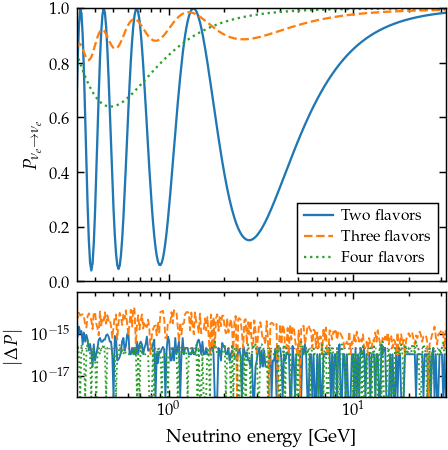

In [4]:
L_LBL = 1300.0*KM      # long baseline, for the two- and three-flavor cases
L_SBL = 0.6*KM         # short baseline, natural for an eV-scale sterile
E_gev = np.logspace(-0.5, 1.5, 300)
E = E_gev*GEV

h2 = hamiltonians2nu.hamiltonian_2nu_matter(
    np.asarray(hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
        gd.S23_NO_BF, gd.D31_NO_BF)), E, gd.VCC_EARTH_CRUST)
h3 = hamiltonians3nu.hamiltonian_3nu_nsi(
    H_VAC_3NU, E, gd.VCC_EARTH_CRUST, gd.EPS_3)
h4 = hamiltonians4nu.hamiltonian_4nu_matter(
    hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF,
        np.sqrt(0.10), np.sqrt(0.10), 0.0,
        gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, 1.0),
    E, gd.VCC_EARTH_CRUST, gd.VNC_EARTH_CRUST)

p2 = oscprob2nu.probabilities_2nu(h2, L_LBL)[:, 0]
p3 = oscprob3nu.probabilities_3nu(h3, L_LBL)[:, 0]
p4 = oscprob4nu.probabilities_4nu(h4, L_SBL)[:, 0]


def by_expm(h_stack, baseline):
    """P_ee from direct numerical exponentiation of the same Hamiltonian."""
    return np.array([abs(expm(-1j*np.asarray(h)*baseline)[0, 0])**2.0
                     for h in np.asarray(h_stack)])


r2 = by_expm(h2, L_LBL)
r3 = by_expm(h3, L_LBL)
r4 = by_expm(h4, L_SBL)
for n, p, r in ((2, p2, r2), (3, p3, r3), (4, p4, r4)):
    print("%d flavors: max |closed form - expm| = %.1e"
          % (n, np.abs(p-r).max()))

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.06), sharex=True,
    gridspec_kw={'height_ratios': [2.6, 1.0], 'hspace': 0.06})

for p, r, lab, ls in ((p2, r2, "Two flavors", "-"),
                      (p3, r3, "Three flavors", "--"),
                      (p4, r4, "Four flavors", ":")):
    # The reference curve lies under the closed-form one to round-off, so
    # plotting it would only overdraw; the lower panel carries the comparison.
    ax.semilogx(E_gev, p, ls, label=lab)
    axr.loglog(E_gev, np.abs(p-r) + 1.0e-18, ls, lw=0.9)

ax.set_ylabel(r"$P_{\nu_e \to \nu_e}$")
ax.set_ylim(0.0, 1.0)
framed(ax, loc="lower right")
axr.axhline(2.2e-16, color="0.45", ls=":", lw=0.7)
axr.set_ylabel(r"$|\Delta P|$")
axr.set_xlabel("Neutrino energy [GeV]")
axr.set_xlim(E_gev[0], E_gev[-1])
axr.set_ylim(1.0e-18, 1.0e-13)
axr.set_yticks([1.0e-17, 1.0e-15])
fig.savefig(os.path.join(FIGDIR, "validation.pdf"))
plt.show()

## Three flavors, four scenarios

Vacuum, constant-density matter, matter with non-standard interactions, and a
CPT-odd Lorentz invariance-violating background, at $L = 1300$ km. All four use
the default parameters in `globaldefs`, so the figure is reproducible from the
repository alone.

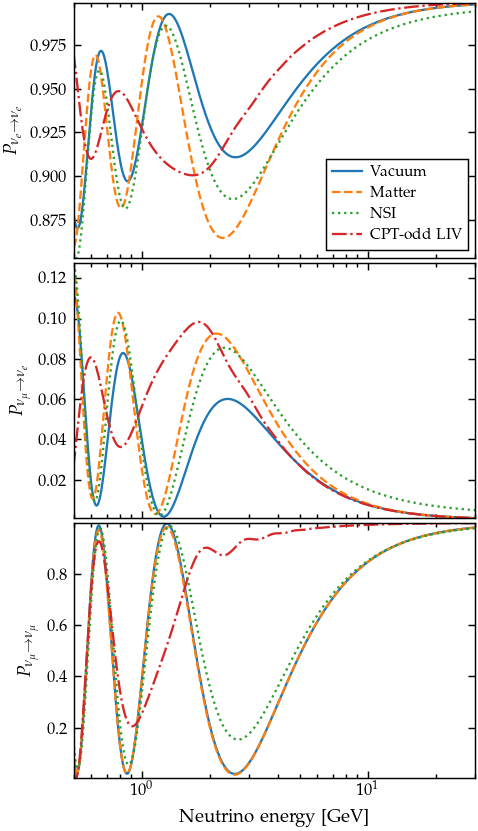

In [5]:
L = 1300.0*KM
E_gev = np.logspace(np.log10(0.5), np.log10(30.0), 400)
E = E_gev*GEV

p = {
    "Vacuum": oscprob3nu.probabilities_3nu(
        np.asarray(H_VAC_3NU)/E[:, None, None], L),
    "Matter": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_matter(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_nsi(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST, gd.EPS_3), L),
    "CPT-odd LIV": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_liv(
            H_VAC_3NU, E, gd.SXI12, gd.SXI23, gd.SXI13,
            gd.DXICP, gd.B1, gd.B2, gd.B3, gd.LAMBDA), L),
}

panels = [(0, r"$P_{\nu_e \to \nu_e}$"),
          (3, r"$P_{\nu_\mu \to \nu_e}$"),
          (4, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_STACK, sharex=True)
for ax, (k, ylabel) in zip(axes, panels):
    for (name, prob), ls in zip(p.items(), STYLES):
        ax.semilogx(E_gev, prob[:, k], ls, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
framed(axes[0], loc="lower right")
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "prob_3nu_vs_energy_compare.pdf"))
plt.show()

## How the slab composition works

A diagram rather than a calculation: the neutrino crosses slabs of differing
width and density, each solved exactly, and the resulting operators are
multiplied. The ties cross, which is the point --- the slab crossed *first* is
applied first, and so stands *rightmost* in the product.

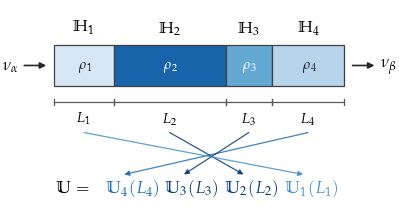

In [6]:
W = [0.9, 1.7, 0.7, 1.1]          # slab widths, arbitrary units
SHADE = [0.16, 0.80, 0.52, 0.30]  # shading, standing in for density
edges = np.concatenate(([0.0], np.cumsum(W)))
total = edges[-1]
cmap = plt.get_cmap("Blues")
fill = [cmap(s) for s in SHADE]
ink = [cmap(np.clip(s + 0.46, 0.62, 0.95)) for s in SHADE]

fig, ax = plt.subplots(figsize=(COLW, COLW*0.56))
ax.set_axis_off()
ax.set_xlim(-0.60, total + 0.60)
ax.set_ylim(-1.16, 0.80)

for k in range(4):
    ax.add_patch(Rectangle((edges[k], 0.0), W[k], 0.40,
                           facecolor=fill[k], edgecolor="0.25", lw=0.6))
    xc = 0.5*(edges[k] + edges[k+1])
    ax.text(xc, 0.48, r"$\mathbb{H}_%d$" % (k+1), ha="center", va="bottom",
            fontsize=7.5)
    ax.text(xc, 0.20, r"$\rho_%d$" % (k+1), ha="center", va="center",
            fontsize=7, color="white" if SHADE[k] > 0.5 else "0.15")
    ax.plot([edges[k], edges[k+1]], [-0.15, -0.15], color="0.35", lw=0.6)
    for e in (edges[k], edges[k+1]):
        ax.plot([e, e], [-0.12, -0.18], color="0.35", lw=0.6)
    ax.text(xc, -0.24, r"$L_%d$" % (k+1), ha="center", va="top", fontsize=7)

for x0, dx in ((-0.52, 0.46), (total + 0.06, 0.46)):
    ax.add_patch(FancyArrowPatch((x0, 0.20), (x0 + dx, 0.20),
                                 arrowstyle="-|>", mutation_scale=6,
                                 lw=0.8, color="0.15"))
ax.text(-0.56, 0.20, r"$\nu_\alpha$", ha="right", va="center", fontsize=8)
ax.text(total + 0.56, 0.20, r"$\nu_\beta$", ha="left", va="center",
        fontsize=8)

y_eq = -0.98
ax.text(0.02, y_eq, r"$\mathbb{U} =$", ha="left", va="center", fontsize=8)
step = (total - 0.78)/4.0
fx = 0.78 + np.arange(4)*step
for k in range(4):
    j = 3 - k                     # factor 4 leftmost, factor 1 rightmost
    ax.text(fx[k], y_eq, r"$\mathbb{U}_%d(L_%d)$" % (j+1, j+1),
            ha="left", va="center", fontsize=8, color=ink[j])
    ax.annotate("", xy=(fx[k] + 0.5*step*0.62, y_eq + 0.14),
                xytext=(0.5*(edges[j] + edges[j+1]), -0.44),
                arrowprops=dict(arrowstyle="-|>", mutation_scale=5,
                                lw=0.6, color=ink[j], alpha=0.85,
                                shrinkA=0, shrinkB=0))

fig.savefig(os.path.join(FIGDIR, "slabs_composition.pdf"))
plt.show()

## An oscillogram through the Earth

Muon-neutrino survival across energy and arrival direction, through the PREM
density profile. Each chord is decomposed into slabs, each solved exactly.

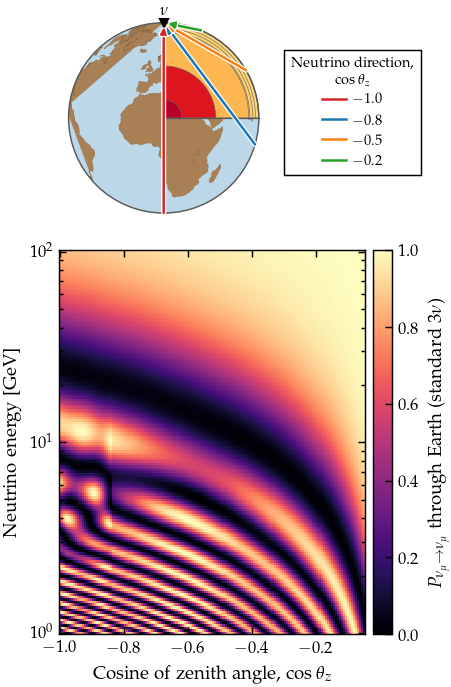

In [7]:
n_e, n_c = 150, 150
E_gev = np.logspace(0.0, 2.0, n_e)
cz = np.linspace(-0.999, -0.05, n_c)

# The whole oscillogram in one call: energies and angles are indexed on
# separate axes and broadcast against each other, so the routine builds
# each chord's geometry once and spreads every energy over the fused
# kernel.  Index 4 of the nine probabilities is P(nu_mu -> nu_mu).
grid = earth.probabilities_3nu_earth(
    H_VAC_3NU, E_gev[:, None]*GEV, cz[None, :],
    n_slabs_per_segment=4)[..., 4]

fig, (axe, ax) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.78),
    gridspec_kw={"height_ratios": [1.30, 1.9], "hspace": 0.02})

# --- Earth in cutaway, with the PREM layers and a few chords.
# Coastlines are the public-domain GSHHS crude polygons, vendored beside
# this notebook so that the figure needs no mapping library.
with open('coastlines_crude.json') as handle:
    COASTS = json.load(handle)['polygons']

LAT0, LON0 = np.deg2rad(22.0), np.deg2rad(12.0)


def ortho(lon_deg, lat_deg):
    """Orthographic projection; the third return is the visibility mask."""
    lon, lat = np.deg2rad(lon_deg), np.deg2rad(lat_deg)
    cosc = (np.sin(LAT0)*np.sin(lat)
            + np.cos(LAT0)*np.cos(lat)*np.cos(lon - LON0))
    return (np.cos(lat)*np.sin(lon - LON0),
            np.cos(LAT0)*np.sin(lat) - np.sin(LAT0)*np.cos(lat)
            * np.cos(lon - LON0),
            cosc)


R = gd.EARTH_RADIUS
r_edge = np.concatenate(([0.0], earth.PREM_BOUNDARIES, [R]))
r_mid = 0.5*(r_edge[:-1] + r_edge[1:])
rho_shell = np.array([earth.density_prem(r) for r in r_mid])
shade = (rho_shell - rho_shell.min())/(rho_shell.max() - rho_shell.min())

axe.add_patch(Circle((0.0, 0.0), 1.0, facecolor="#bcd7e8", edgecolor="none",
                     zorder=1))
for seg in COASTS:
    seg = np.asarray(seg)
    x, y, cosc = ortho(seg[:, 0], seg[:, 1])
    if (cosc > 0.0).sum() < 3:
        continue
    axe.add_patch(Polygon(np.column_stack([x[cosc > 0.0], y[cosc > 0.0]]),
                          closed=True, facecolor="#a98055",
                          edgecolor="#8a6640", lw=0.15, zorder=2))
axe.add_patch(Circle((0.0, 0.0), 1.0, facecolor="none", edgecolor="0.35",
                     lw=0.7, zorder=6))

# The quarter cutaway, top right, showing the PREM layers.
cmap_e = plt.get_cmap("YlOrRd")
for rb, sh in zip(r_edge[1:][::-1], shade[::-1]):
    axe.add_patch(Wedge((0.0, 0.0), rb/R, 0.0, 90.0, zorder=3, lw=0.3,
                        facecolor=cmap_e(0.10 + 0.78*sh), edgecolor="0.40"))
axe.plot([0.0, 0.0], [0.0, 1.0], color="0.35", lw=0.6, zorder=4)
axe.plot([0.0, 1.0], [0.0, 0.0], color="0.35", lw=0.6, zorder=4)

for c, col in zip((-1.0, -0.8, -0.5, -0.2),
                  ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c"]):
    phi = 2.0*np.arcsin(min(1.0, -c))
    axe.annotate("", xy=(0.0, 1.0), xytext=(np.sin(phi), np.cos(phi)),
                 zorder=7,
                 arrowprops=dict(arrowstyle="-|>", mutation_scale=6, lw=1.2,
                                 color=col, shrinkA=0, shrinkB=2,
                                 path_effects=[
                                     pe.Stroke(linewidth=2.4,
                                               foreground="white"),
                                     pe.Normal()]))
    axe.plot([], [], "-", color=col, lw=1.2, label=r"$%.1f$" % c)
axe.plot(0.0, 1.0, "v", color="k", ms=4.2, zorder=8)
axe.text(0.0, 1.125, r"$\nu$", color="k", fontsize=8, ha="center",
         va="center", zorder=8)
axe.set_aspect("equal")
axe.set_axis_off()
axe.set_xlim(-1.10, 2.78)
axe.set_ylim(-1.10, 1.21)
leg_e = axe.legend(loc="center right", fontsize=7, borderpad=0.45,
                   handlelength=1.6, handletextpad=0.5, labelspacing=0.4,
                   title="Neutrino direction,\n" + r"$\cos\theta_z$")
leg_e.get_frame().set_linewidth(0.7)
leg_e.get_title().set_fontsize(7)
leg_e.get_title().set_multialignment("center")

mesh = ax.pcolormesh(cz, E_gev, grid, shading="auto", cmap="magma",
                     vmin=0.0, vmax=1.0, rasterized=True)
ax.set_yscale("log")
ax.set_xlabel(r"Cosine of zenith angle, $\cos\theta_z$")
ax.set_ylabel("Neutrino energy [GeV]")
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(r"$P_{\nu_\mu \to \nu_\mu}$ through Earth "
               r"(standard $3\nu$)")
cbar.outline.set_linewidth(0.7)
fig.savefig(os.path.join(FIGDIR, "earth_oscillogram.pdf"))
plt.show()

## The arrangement of matter, not only its mean

Four density profiles with the *same* mean density, and indeed the same
multiset of slabs, give different probabilities. The upper panel shows the
profiles; the lower one, what they do.

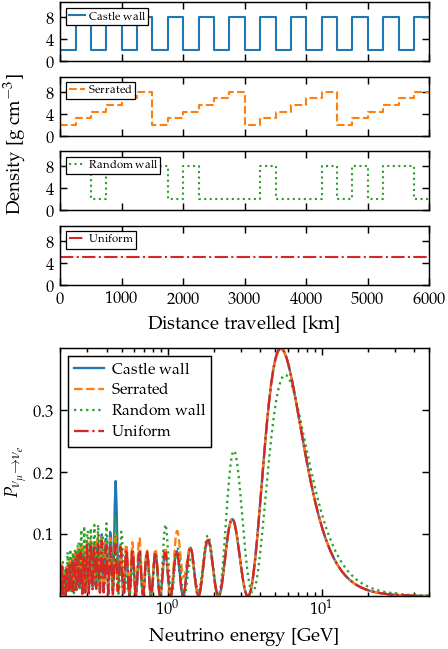

In [8]:
def probabilities_profile(widths_km, densities, energy_ev, h_vac=None):
    """Nine probabilities through an arbitrary matter profile.

    An array of energies gives a stack of chords sharing the widths,
    which `slabs` composes in one pass rather than one energy at a time.
    """
    h_vac = H_VAC_3NU if h_vac is None else h_vac
    vcc = earth.matter_potential(np.asarray(densities, dtype=float))
    energy = np.asarray(energy_ev, dtype=float)
    if energy.ndim:
        energy = energy[:, None]
    H = hamiltonians3nu.hamiltonian_3nu_matter(h_vac, energy, vcc)
    return np.array(slabs.probabilities_3nu_slabs(
        H, np.asarray(widths_km, dtype=float)*KM))


total_km = 6000.0
n_slab = 24
rho_lo, rho_hi = 2.0, 8.0
mean_rho = 0.5*(rho_lo + rho_hi)

widths = np.full(n_slab, total_km/n_slab)
castle = np.where(np.arange(n_slab) % 2 == 0, rho_lo, rho_hi)
serrated = np.tile(np.linspace(rho_lo, rho_hi, 6), 4)
rng = np.random.default_rng(20260801)
# A *permutation* of the castle wall, not a fresh random draw: that guarantees
# the identical multiset of slabs, and so exactly the same mean density, which
# is the whole premise of the comparison.
random_wall = rng.permutation(castle)
uniform = np.full(n_slab, mean_rho)

profiles = [("Castle wall", castle), ("Serrated", serrated),
            ("Random wall", random_wall), ("Uniform", uniform)]
E_gev = np.logspace(-0.7, 1.7, 400)

fig = plt.figure(figsize=(COLW, COLW*1.62))
# Row 4 is left empty, as a gap between the profiles and the probabilities.
gs = fig.add_gridspec(6, 1, height_ratios=[1.0, 1.0, 1.0, 1.0, 0.55, 4.2],
                      hspace=0.18)
axes_p = [fig.add_subplot(gs[i]) for i in range(4)]
ax = fig.add_subplot(gs[5])

edges = np.concatenate(([0.0], np.cumsum(widths)))
for axp, (name, rho), ls, c in zip(axes_p, profiles, STYLES,
                                   ["C0", "C1", "C2", "C3"]):
    axp.step(edges, np.concatenate((rho[:1], rho)), ls, where="pre",
             lw=1.0, color=c, label=name)
    axp.set_xlim(0.0, edges[-1])
    axp.set_ylim(0.0, rho_hi*1.35)
    axp.set_yticks([0.0, 4.0, 8.0])
    leg = axp.legend(loc="upper left", handlelength=1.4, borderpad=0.25,
                     handletextpad=0.4, fontsize=5.5)
    leg.get_frame().set_linewidth(0.6)
    if axp is not axes_p[-1]:
        axp.set_xticklabels([])
axes_p[-1].set_xlabel("Distance travelled [km]")
# One y-label, centred on the four profile panels.
pos_top = axes_p[0].get_position(fig)
pos_bot = axes_p[-1].get_position(fig)
fig.text(0.005, 0.5*(pos_top.y1 + pos_bot.y0), r"Density [g cm$^{-3}$]",
         rotation="vertical", va="center", ha="left", fontsize=9)

for (name, rho), ls, c in zip(profiles, STYLES, ["C0", "C1", "C2", "C3"]):
    # The whole 400-energy scan in one call
    p = probabilities_profile(widths, rho, E_gev*GEV)[:, 3]
    ax.semilogx(E_gev, p, ls, color=c, label=name)
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel(r"$P_{\nu_\mu \to \nu_e}$")
leg = ax.legend(loc="upper left", ncol=1, fontsize=7.5)
leg.get_frame().set_linewidth(0.7)
fig.savefig(os.path.join(FIGDIR, "density_arrangement.pdf"))
plt.show()

## A 3+1 sterile resonance through the Earth

Four flavors, antineutrinos, through the full PREM profile: the matter
resonance that a three-flavor treatment cannot produce at all. Because the
resonance follows the density, it sits at a different energy for chords that
cross the core than for chords that stay in the mantle.

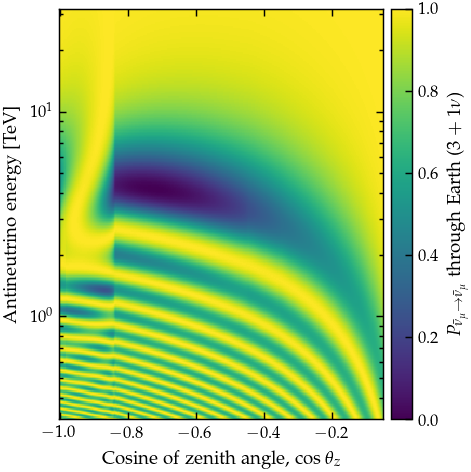

In [9]:
DM41 = 1.0                       # [eV^2]
S14 = S24 = np.sqrt(0.10)
S34 = 0.0

H_VAC_4NU = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, S14, S24, S34,
    gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, DM41)

n_e, n_c = 300, 300
E_tev = np.logspace(-0.5, 1.5, n_e)          # 0.3 - 30 TeV
costhz = np.linspace(-1.0, -0.05, n_c)

# Antineutrinos on the full PREM profile, in one call.  `earth` builds
# the slabs, conjugates the vacuum term and reverses both potentials --
# a sterile state feels neither, so V_NC no longer cancels between the
# flavors and is carried per slab alongside V_CC.  Energies and angles
# go on separate axes; index 5 of the sixteen is P(nu_mu -> nu_mu).
grid = earth.probabilities_4nu_earth(
    H_VAC_4NU, E_tev[:, None]*1.0e3*GEV, costhz[None, :],
    n_slabs_per_segment=4, antineutrino=True)[..., 5]

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
mesh = ax.pcolormesh(costhz, E_tev, grid, shading="auto",
                     cmap="viridis", vmin=0.0, vmax=1.0, rasterized=True)
ax.set_yscale("log")
ax.set_xlabel(r"Cosine of zenith angle, $\cos\theta_z$")
ax.set_ylabel("Antineutrino energy [TeV]")
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(r"$P_{\bar\nu_\mu \to \bar\nu_\mu}$ through Earth "
               r"($3+1\nu$)")
cbar.outline.set_linewidth(0.7)
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "sterile_earth_oscillogram.pdf"))
plt.show()

## How the pieces fit together

A map of the library: what each module is responsible for, and how a
Hamiltonian becomes a probability.

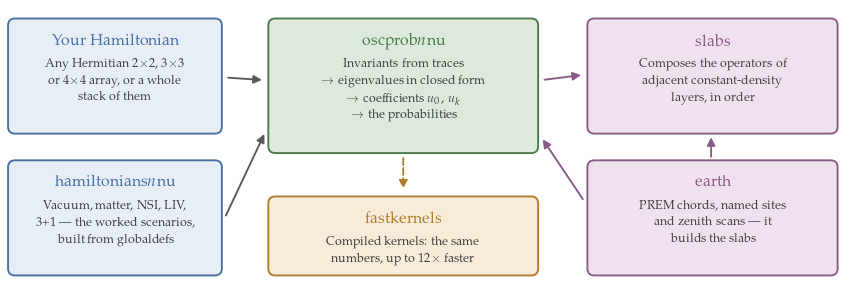

In [10]:
from matplotlib.patches import FancyBboxPatch

# Two columns wide: TEXTW is the paper's \textwidth.
TEXTW = 522.0/72.27

fig, axd = plt.subplots(figsize=(TEXTW, TEXTW*0.34))
axd.set_axis_off()
axd.set_xlim(0.0, 30.0)
axd.set_ylim(0.0, 10.2)

C_IN, C_CORE, C_ACC, C_COMP = "#e8eef6", "#dce9dc", "#f6ecd9", "#efe2ee"
E_IN, E_CORE, E_ACC, E_COMP = "#4a6fa5", "#4a7a4a", "#b07d2a", "#8a5a86"


def box(x, y, w, h, face, edge, title, body):
    axd.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.12,rounding_size=0.25",
        facecolor=face, edgecolor=edge, lw=0.9, zorder=2))
    axd.text(x + w/2.0, y + h - 0.42, title, ha="center", va="top",
             fontsize=7.6, color=edge, zorder=3,
             fontfamily="monospace" if title[0].islower() else None)
    if body:
        axd.text(x + w/2.0, y + h - 1.30, body, ha="center", va="top",
                 fontsize=6.0, color="0.25", zorder=3, linespacing=1.5)


def arrow(x0, y0, x1, y1, color="0.35", ls="-"):
    axd.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=1,
                 arrowprops=dict(arrowstyle="-|>", mutation_scale=8, lw=0.9,
                                 color=color, linestyle=ls, shrinkA=2,
                                 shrinkB=2))


# Left: what goes in.  Middle: the library proper.  Right: layered matter.
box(0.3, 5.6, 7.4, 3.9, C_IN, E_IN, "Your Hamiltonian",
    "Any Hermitian $2{\\times}2$, $3{\\times}3$\nor $4{\\times}4$ array, or a whole\nstack of them")
box(0.3, 0.5, 7.4, 3.9, C_IN, E_IN, "hamiltonians$n$nu",
    "Vacuum, matter, NSI, LIV,\n3+1 --- the worked scenarios,\nbuilt from globaldefs")

# The green box was 5.0 tall for four lines of body, leaving its lower half
# empty, and its rounded corner met the orange box's: 2.6 against 2.5, minus
# 0.12 of padding each, overlapped them.  Shortened, and moved up to leave a
# clear 0.5 between the two.
# The middle column is aligned with the two flanking pairs: the core box's
# top with the upper boxes, the kernel box's bottom with the lower ones.
box(9.6, 4.9, 9.4, 4.6, C_CORE, E_CORE, "oscprob$n$nu",
    "Invariants from traces\n"
    "$\\rightarrow$ eigenvalues in closed form\n"
    "$\\rightarrow$ coefficients $u_0,\\, u_k$\n"
    "$\\rightarrow$ the probabilities")
box(9.6, 0.5, 9.4, 2.6, C_ACC, E_ACC, "fastkernels",
    "Compiled kernels: the same\nnumbers, up to $12{\\times}$ faster")

box(21.0, 5.6, 8.7, 3.9, C_COMP, E_COMP, "slabs",
    "Composes the operators of\nadjacent constant-density\nlayers, in order")
box(21.0, 0.5, 8.7, 3.9, C_COMP, E_COMP, "earth",
    "PREM chords, named sites\nand zenith scans --- it\nbuilds the slabs")

arrow(7.9, 7.5, 9.4, 7.4)
arrow(7.9, 2.4, 9.4, 5.6)
arrow(14.3, 4.75, 14.3, 3.35, color=E_ACC, ls="--")
arrow(19.2, 7.4, 20.8, 7.6, color=E_COMP)
arrow(20.8, 3.0, 19.2, 5.4, color=E_COMP)
arrow(25.3, 4.5, 25.3, 5.5, color=E_COMP)
fig.savefig(os.path.join(FIGDIR, "architecture.pdf"),
            bbox_inches="tight", pad_inches=0.02)
plt.show()

## A long-range interaction through the Earth

The point of an *arbitrary* Hamiltonian is that a scenario nobody has written
a formula for costs no more than one that has been solved for decades.  This
is the example the paper uses to make that concrete: a gauged $L_e - L_\mu$
interaction, in which the electrons of the Earth source a Yukawa potential
that the neutrino feels as a term added to the matter Hamiltonian.

Unlike $V_{\rm CC}$, that potential is *non-local* --- it depends on how many
electrons there are and only weakly on where they sit --- so it cannot be
folded into an effective density profile, and no tailored expression exists
for it.  It is still only a Hermitian matrix, so the library takes it.

Everything the figure needs is repeated here rather than imported, so that
this notebook does not depend on `20_arbitrary_hamiltonian.ipynb`, which is
where the potential is built up, checked against its two limits, and
validated.

In [11]:
def shc(x):
    """sinh(x)/x, continued to 1 at the origin."""
    safe = np.where(x == 0.0, 1.0, x)
    return np.where(x == 0.0, 1.0, np.sinh(safe)/safe)


def yukawa_potential(r, radii, n_e, m_mediator, alpha):
    """V_emu [eV] at radii `r`, from a ball of electrons.

    `r`, `radii` and 1/`m_mediator` in eV^-1, `n_e` in eV^3, and
    `alpha` = g^2/(4 pi) for the new gauge coupling g.
    """
    f = radii*n_e
    a = f*radii*shc(m_mediator*radii)
    inner = np.concatenate(([0.0], np.cumsum(
        0.5*(a[1:]+a[:-1])*np.diff(radii))))

    # The exterior piece is accumulated *inward* from the surface.  Taking
    # it as (total - interior) is the obvious thing to write and is wrong:
    # once exp(-m R) is small the tail is a difference of two nearly equal
    # numbers and vanishes into round-off.
    b = f*np.exp(-m_mediator*radii)
    d = 0.5*(b[1:]+b[:-1])*np.diff(radii)
    outer = np.concatenate((np.cumsum(d[::-1])[::-1], [0.0]))

    r = np.asarray(r, dtype=float)
    safe = np.where(r == 0.0, 1.0, r)          # the 1/r is removable
    return 4.0*np.pi*alpha*np.where(
        r == 0.0, np.interp(r, radii, outer),
        np.exp(-m_mediator*safe)*np.interp(r, radii, inner)/safe
        + shc(m_mediator*safe)*np.interp(r, radii, outer))


# nu_e carries +1 of the gauged charge and nu_mu carries -1.
Q_LR = np.diag([1.0, -1.0, 0.0])
R_E = gd.EARTH_RADIUS*KM

# n_e is read back from the library's own V_CC, rather than repeating the
# density-to-electron-number conversion here and risking a different one.
_edges = np.concatenate(([0.0], earth.PREM_BOUNDARIES, [gd.EARTH_RADIUS]))
_radii = np.concatenate([np.linspace(lo, hi, 201) for lo, hi
                         in zip(_edges[:-1], _edges[1:]) if hi > lo])
_inside = np.clip(_radii, 1.0e-9, gd.EARTH_RADIUS)
NE_EARTH = (earth.matter_potential(earth.density_prem(_inside))
            /(np.sqrt(2.0)*gd.GF))
RADII_EARTH = _radii*KM

COSZ_LRI = -1.0                  # straight through, along a diameter
M_LRI = 1.0/R_E                  # range of the force equal to R_earth
ALPHA_LRI = 1.0e-52
# Densely sampled: below about 2 GeV the diameter is many oscillation
# lengths, and a coarser grid aliases those wiggles rather than resolving
# them.
E_LRI = np.logspace(np.log10(1.0), np.log10(40.0), 500)

WIDTHS_LRI, DENS_LRI = earth.earth_slabs(COSZ_LRI, n_slabs_per_segment=24)
_edge = np.concatenate(([0.0], np.cumsum(WIDTHS_LRI)))
_mid = 0.5*(_edge[:-1] + _edge[1:])
R_SLAB = earth.earth_radial_distance_from_depth(COSZ_LRI, _mid)*KM
VCC_LRI = earth.matter_potential(DENS_LRI)
V_LRI = yukawa_potential(R_SLAB, RADII_EARTH, NE_EARTH, M_LRI, ALPHA_LRI)
print("V_CC at the centre  : %.3e eV" % VCC_LRI[len(VCC_LRI)//2])
print("V_emu at the centre : %.3e eV" % V_LRI[len(V_LRI)//2])


def p_mue_lri(energy_ev, with_lri):
    """P(nu_mu -> nu_e) along the chord, with or without the new term.

    The energies stack on a leading axis, so the whole scan is one call:
    (n_energies, n_slabs, 3, 3) against the widths the chords share.
    """
    h = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, np.asarray(energy_ev)[:, None], VCC_LRI))
    if with_lri:
        h = h + V_LRI[:, None, None]*Q_LR
    return np.array(slabs.probabilities_3nu_slabs(
        h, WIDTHS_LRI*KM))[:, 3]


P_STD_LRI = p_mue_lri(E_LRI*GEV, False)
P_NEW_LRI = p_mue_lri(E_LRI*GEV, True)
print("largest |dP| = %.3f, at E = %.1f GeV"
      % (np.max(np.abs(P_NEW_LRI-P_STD_LRI)),
         E_LRI[np.argmax(np.abs(P_NEW_LRI-P_STD_LRI))]))

V_CC at the centre  : 4.955e-13 eV
V_emu at the centre : 5.817e-15 eV
largest |dP| = 0.098, at E = 4.1 GeV


The upper panel is the probability itself and the lower one the
difference the new interaction makes, on a scale where it is
visible.

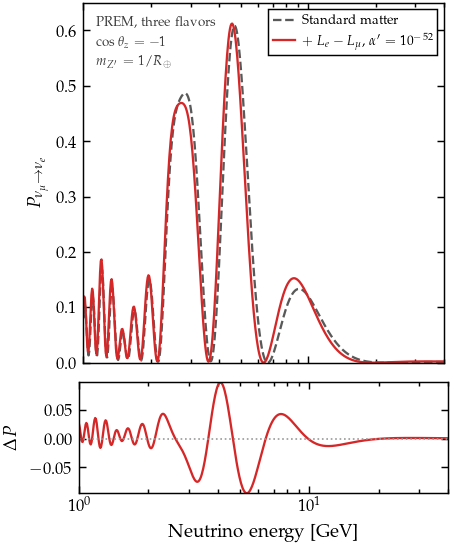

In [12]:
fig, (ax, axd) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.34), sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.0], "hspace": 0.08})

ax.semilogx(E_LRI, P_STD_LRI, "--", color="0.35", lw=1.1,
            label="Standard matter")
ax.semilogx(E_LRI, P_NEW_LRI, "-", color="C3", lw=1.1,
            label=r"$+\ L_e - L_\mu$, $\alpha^\prime = 10^{-52}$")
ax.set_ylabel(r"$P_{\nu_\mu \to \nu_e}$")
# The two curves peak at 0.608 and 0.612, so anything at or below 0.61
# clips them; 0.65 is tight while leaving the peaks whole and giving the
# legend somewhere to sit.
ax.set_ylim(0.0, 0.65)
# Three short lines rather than two long ones: the second line of a
# two-line version runs under the legend box.
ax.text(0.035, 0.96,
        "PREM, three flavors\n"
        + r"$\cos\theta_z = -1$" + "\n"
        + r"$m_{Z^\prime} = 1/R_\oplus$",
        transform=ax.transAxes, ha="left", va="top", fontsize=6.5,
        color="0.25", linespacing=1.6)
leg = ax.legend(loc="upper right", fontsize=6.5, handlelength=1.6)
leg.get_frame().set_linewidth(0.7)
# The main panel is square, like the other figures in this notebook; the
# residual strip below it is a fixed fraction of that.
ax.set_box_aspect(1.0)
axd.set_box_aspect(0.30)

axd.semilogx(E_LRI, P_NEW_LRI-P_STD_LRI, "-", color="C3", lw=1.1)
axd.axhline(0.0, color="0.6", ls=":", lw=0.8)
axd.set_ylabel(r"$\Delta P$")
axd.set_xlabel("Neutrino energy [GeV]")
axd.set_xlim(E_LRI[0], E_LRI[-1])
fig.savefig(os.path.join(FIGDIR, "lri_earth.pdf"))
plt.show()

## Speed and accuracy, against five other codes

Every code here solves the *same* problem and is refereed by the *same*
arbitrary-precision reference, so that none of them is its own judge.

The external numbers are frozen in `tests/speed_accuracy.json`; the cell below
records exactly how each was obtained, so the comparison can be reproduced or
disputed without guessing what was run.

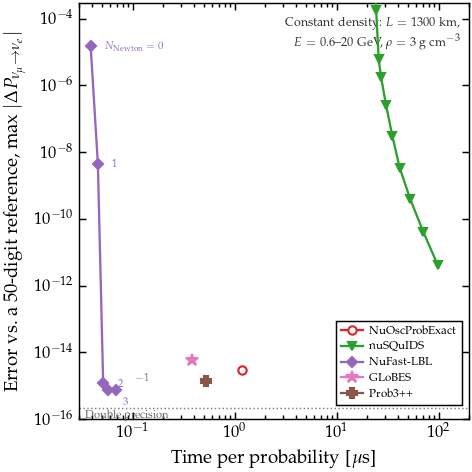

In [13]:
# ---------------------------------------------------------------------------
# Provenance of the external numbers.  None of these codes is needed to run
# this notebook: the results are frozen in tests/speed_accuracy.json.  What
# follows is exactly what was done to produce them, on Linux, August 2026.
#
# TWO CONVENTIONS ARE MATCHED FIRST, or the comparison measures bookkeeping
# rather than physics:
#
#   Matter potential.  This library takes n_e = Y_e rho / m_bar, with m_bar the
#   mean free-nucleon mass; the others take rho N_A Y_e.  The ratio is the
#   nuclear mass defect,
#       scale = (CONV_G_TO_EV/((MASS_PROTON+MASS_NEUTRON)/2)) / N_A = 0.99209
#   and each external code is handed rho*scale = 2.97628 g/cm^3 so that all
#   propagate with the same V_CC.  (For GLoBES this factor was *found* by
#   scanning the density, and the minimum landed on 0.99209 to a part in 1e7 --
#   an independent check that the reasoning above is right.)
#
#   Length unit.  The codes disagree on hbar*c in the 7th digit:
#       this library  5.0677300000e9   eV^-1 per km
#       nuSQuIDS      5.0677307162e9
#       NuFast-LBL    5.0677302143e9   ( = 1e3 / 1.97327e-7 )
#   so each is given the baseline in km that reproduces *our* L in eV^-1.
#   NuFast and Prob3++ and GLoBES get 1299.999945 km instead of 1300.
#
# THE REFEREE.  Accuracy is measured against a 50-digit mpmath matrix
# exponential of the same Hamiltonian:
#     mp.mp.dps = 50;  U = mp.expm(-1j*M*mp.mpf(L));  P = abs(U[0,1])**2
# This library agrees with it to 4e-17, which is why it can be plotted at
# "double precision" rather than at zero.
#
# ---------------------------------------------------------------------------
# nuSQuIDS 1.13.3 -- manylinux wheel, no compiler needed:
#     pip install nusquids            # imports as `nuSQuIDS`
#   Multiple-energy mode, Set_rel_error = Set_abs_error swept over
#   1e-4 ... 1e-12.  Timed through the Python interface, including building
#   the solver and reading the results back.  Note its own default tolerance
#   is far tighter and ~40x slower than an explicit 1e-12.
#
# NuFast-LBL -- header-only C++, not on PyPI:
#     git clone https://github.com/PeterDenton/NuFast-LBL.git
#     g++ -Ofast -ffast-math driver.cpp -o driver
#   Probability_Matter_LBL(...), sweeping N_Newton = 0,1,2,3.  Timed inside
#   C++, best of five, with no Python in the loop.  rhoYe = 1.488737 (that is
#   3*0.5*0.99209).  N_Newton = 0 is its default and is a truncation, not an
#   error: two steps reach 8e-12.
#
# GLoBES 3.2.18 -- needs GSL (2.7.1 here):
#     curl -O https://www.mpi-hd.mpg.de/personalhomes/globes/download/globes-3.2.18.tar.gz
#     tar xzf globes-3.2.18.tar.gz && cd globes-3.2.18
#     ./configure --prefix=$PREFIX --with-gsl-prefix=/usr && make && make install
#     gcc -O2 -I$PREFIX/include drv.c -L$PREFIX/lib -lglobes -lgsl -lgslcblas -lm
#   glbConstantDensityProbability(2, 1, +1, E, L, rho), after glbDefineParams
#   with angles as arcsin(sqrt(sin^2 theta)) and glbSetOscillationParameters.
#
# Prob3++ -- C++; mosc.c and mosc3.c must be compiled as C, not C++:
#     git clone https://github.com/rogerwendell/Prob3plusplus.git
#     gcc -O2 -c mosc.c mosc3.c ; g++ -O2 -c EarthDensity.cc BargerPropagator.cc
#     g++ -O2 drv.cpp mosc.o mosc3.o EarthDensity.o BargerPropagator.o
#   BargerPropagator::SetMNS(s12sq, s13sq, s23sq, dm21, dmAtm, dcp, E, true, 1)
#   then propagateLinear(1, L, rho) and GetProb(2, 1).
#   CAUTION: the fifth argument is Dm2_32, NOT Dm2_31.  Passing Dm2_31 leaves a
#   1.7e-2 disagreement that no density rescaling will remove; with
#   Dm2_32 = 2.525e-3 - 7.39e-5 it drops to 4.5e-5.
#
# nuCraft r22 -- pure Python, installs by unpacking:
#     curl -O https://nucraft.hepforge.org/nuCraft-r22.tar.gz && tar xzf ...
#   NOT included here: its interface is (PDG type, energy, zenith angle) and it
#   propagates through its own Earth model, with no constant-density mode, so
#   it belongs in an Earth comparison rather than this one.  Two of its
#   conventions would need matching there: default electron fractions
#   y = (0.4957, 0.4656, 0.4656) rather than 0.5, and a default rICore of
#   1121.5 km against the 1221.5 km in its own PREM density table.
# ---------------------------------------------------------------------------

import json

with open(os.path.join('..', 'tests', 'speed_accuracy.json')) as handle:
    sa = json.load(handle)

# The same colours, markers and layout as the two Earth planes, so that a
# code keeps its identity across all three.  This library shows only the
# batched-plus-kernel point: the other two routes are what the performance
# figure is for, and here they would be three labels on one horizontal line.
# This library first, then the rest.  dict order is legend order.
#
# NuFast-Earth is measured at constant density -- it does have that mode,
# and the artifact is kept -- but it is not drawn here: this figure is the
# constant-density comparison and an Earth propagator does not belong on
# it.  The one thread variant is not drawn either, for a plainer reason:
# at constant density it lands at 1.1704 us against 1.1703, so it was a
# second legend entry sitting exactly underneath the first marker.
STYLE = {"NuOscProbExact": ("-o", "C3", 4.0),
         "nuSQuIDS": ("-v", "C2", 3.6),
         "NuFast-LBL": ("-D", "C4", 3.2),
         "GLoBES": ("-*", "C6", 6.0),
         "Prob3++": ("-P", "C5", 4.4)}

# Only the fastest point at each accuracy is drawn.  Four of these codes
# have an INERT dial here: at constant density there is no profile to
# subdivide, so every shell or slab setting returns the same answer and the
# sweep is a stack of points at one height.  Drawing all of them would say
# nothing; drawing the slowest would report the code as slower than anyone
# would ever run it.  NuFast-LBL and NuFast-Earth keep their curves, since
# their dial is the eigenvalue solve and does move the accuracy.
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
anchor = {}
for name in STYLE:
    series = next((x for x in sa["series"] if x["name"] == name), None)
    if series is None:
        continue
    marker, colour, size = STYLE[name]
    points = [q for q in series["points"]
              if q.get("best_at_this_accuracy", True)
              and q["max_abs_error"] is not None]
    if not points:
        continue
    # Ordered along the curve by error, not by knob value.  Sorting by knob
    # put N_Newton = -1 -- the exact mode, at the accurate end -- before 0,
    # the least accurate, so the polyline ran bottom, top, bottom and drew a
    # closed loop that read as two separate NuFast-LBL curves.
    points.sort(key=lambda q: (-q["max_abs_error"], q["us_per_probability"]))
    t = [q["us_per_probability"] for q in points]
    e = [q["max_abs_error"] for q in points]
    kw = dict(ms=size, color=colour, label=name, zorder=4)
    if name.startswith("NuOscProbExact"):
        kw.update(mfc="white", mew=1.0, zorder=5)
    ax.loglog(t, e, marker, **kw)
    for q in points:
        anchor[(name, q["label"])] = (
            q["us_per_probability"], q["max_abs_error"], colour)

# What is varied along each curve, at both ends where there are two.
# Anchored to the measured points rather than to typed coordinates: the
# previous version of this figure carried four pairs of numbers copied from
# a run nobody could reproduce, and one of them -- NuFast-LBL at
# N_Newton = 3 -- said 8.3e-12 where the measurement says 7.6e-16.
for (name, label), lab, dx, dy, ha in (
        # The dial's own values, as the paper labels them.  "LBL exact" and
        # "Earth exact" were wording invented here, and the second existed
        # only because NuFast-Earth had been added to this figure.
        (("NuFast-LBL", "0"), r"$N_{\rm Newton} = 0$", 7, -2, "left"),
        (("NuFast-LBL", "1"), "1", 7, -2, "left"),
        (("NuFast-LBL", "2"), "2", 7, -2, "left"),
        (("NuFast-LBL", "-1"), r"$-1$", 9, 4, "left"),
        (("NuFast-LBL", "3"), "3", 7, -7, "left")):
    if (name, label) not in anchor:
        continue
    x, y, c = anchor[(name, label)]
    ax.annotate(lab, xy=(x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=5.2, color=c, ha=ha)

ax.axhline(2.2e-16, color="0.5", ls=":", lw=0.7, zorder=1)
ax.text(3.4e-2, 1.15e-16, "Double precision", fontsize=5.4, color="0.4")
# This panel's data does not leave the same corners free as the Earth ones:
# Placed against where the points actually are, which the measurement
# decides and not this cell: five codes cluster along the double-precision
# floor at the bottom left, NuFast-LBL climbs the left edge as its Newton
# steps are removed, and nuSQuIDS sits alone in the middle right.  That
# leaves the top right empty for the legend.  The previous version of this
# block placed both from a layout the old data had, and also carried an
# "Array + kernel" label pinned to a point -- 0.230 us, 9.71e-16 -- that no
# longer exists in any measurement.
# Upper right, because that corner is genuinely empty and the lower right
# is not: nuSQuIDS is a single point out at 18 us, and an opaque legend
# placed there covered it completely -- the code appeared in the legend and
# nowhere on the axes.
ax.text(0.975, 0.965, "Constant density:  $L = 1300$ km,\n"
        r"$E = 0.6$--$20$ GeV,  $\rho = 3$ g cm$^{-3}$",
        transform=ax.transAxes, ha="right", va="top", fontsize=6.0,
        color="0.2", linespacing=1.4)
ax.set_xlabel(r"Time per probability [$\mu$s]")
ax.set_ylabel(r"Error vs.\ a 50-digit reference,  "
              r"max $|\Delta P_{\nu_\mu \to \nu_e}|$")
ax.set_xlim(3.0e-2, 2.0e2)
ax.set_ylim(1.0e-16, 3.0e-4)
leg = ax.legend(loc="lower right", bbox_to_anchor=(0.995, 0.02),
                fontsize=5.6)
leg.get_frame().set_linewidth(0.7)
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "speed_accuracy.pdf"))
plt.show()

## Speed and accuracy through the Earth

The same plane as above, on the PREM profile rather than at constant density,
at three flavors and at 3+1.

These two measure something different from the figure above, and the
difference is the whole point of them. At constant density there is an exact
answer, and the figure measures how closely each code evaluates it: the floor
is round-off. Through the Earth the density varies continuously, and *every*
code approximates the profile, this one included. So the reference here is a
**converged** PREM solution rather than an exact one, and each code sits where
its treatment of the profile puts it, not where the accuracy of its
probability formula would.

The consequence is that this library is a curve rather than a horizontal line,
with `n_slabs_per_segment` as its dial. That is more informative than a line:
the dial is what a user actually turns, and it keeps converging — second order
in the slab width — through the region where both external codes flatten out.

The external numbers are frozen in `tests/prem_speed_accuracy.json`.

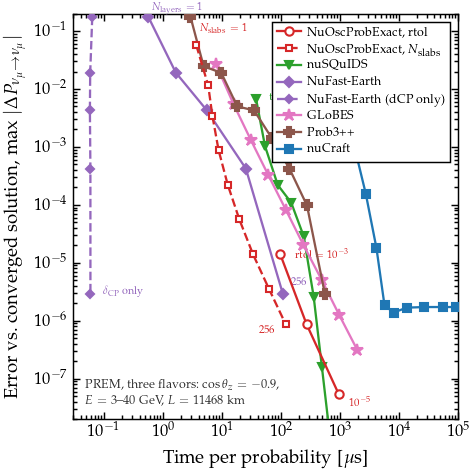

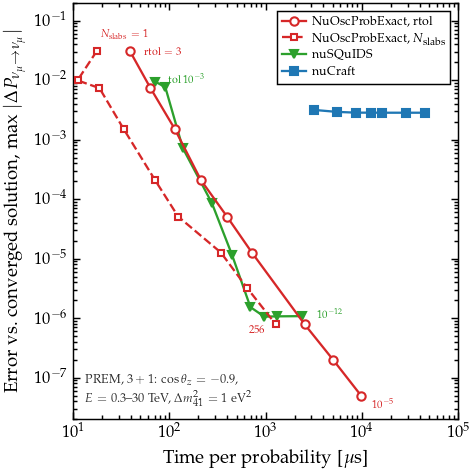

In [14]:
# ---------------------------------------------------------------------------
# Provenance.  Neither external code is needed to run this notebook: the
# results are frozen in tests/prem_speed_accuracy.json.  The generator,
# tests/prem_scan.py, carries the full account in its module docstring --
# every convention matched, how each was established, and the three
# Python 2 remnants in nuCraft r22.  In brief:
#
#   THE REFEREE.  The slab product converges at SECOND order in the slab
#   width: the density is sampled at slab midpoints and the PREM shell
#   boundaries are cut exactly, so the leading error is O(h^2).  Measured
#   exponents are 2.000 at 3, 10 and 40 GeV.  The reference is therefore
#       ref = (4*P(256) - P(128))/3
#   of a 30-digit mpmath slab product -- not the first-order 2*P(32)-P(16),
#   which for this problem amplifies the error instead of cancelling it.
#
#   REFEREEING THE REFEREE.  That extrapolation shares earth.earth_slabs
#   with the code it judges, so it is checked against a discretisation with
#   nothing in common: an adaptive DOP853 integration of
#   dpsi/dx = -i H(x) psi through the continuous profile, restarted at each
#   shell boundary so that no step straddles a discontinuity.  The two
#   agree to 2.3e-11 at three flavors and 1.2e-9 at 3+1.
#
#   nuSQuIDS 1.13.3.  Atmosphere height set to zero (it defaults to 22 km,
#   which lengthens the chord by 24.4 km); cos(theta_z) shrunk by 1.413e-7
#   so that its km reproduces ours in eV^-1 -- in vacuum that takes the
#   agreement from 3.8e-7 to 1.0e-15; this library's PREM handed over
#   through the documented (x, rho, ye) constructor at ye = 0.5 with the
#   usual 0.99209 mass defect, on a grid whose points land exactly on the
#   PREM shell boundaries.  Its ~1e-6 floor is not the integrator: it is
#   identical for RK4, RKF45, RKCK, RK8PD and MSADAMS, for any h_max, and
#   for every tolerance below 1e-9.
#
#   nuCraft r22.  CalcWeights takes the ZENITH ANGLE IN RADIANS while
#   ConstructMixingMatrix takes its angles in degrees; passing degrees to
#   both leaves a disagreement of 0.198.  atmMode 0 with atmHeight 0 and
#   detectorDepth 0 is surface to surface.  Its V_CC constant, 15.256e-5,
#   is the atomic-mass-unit value rather than the mean-nucleon one its own
#   source comment claims, so its density is scaled by 0.9926737; scanning
#   for the minimum residual returns 0.9926748, and the two codes then
#   agree to 3e-11 at constant density.
#
#   nuCraft is flat at 2.8e-3 in the 3+1 panel, and that is not its solver.
#   Its sterile and charged-current entries come from two independently
#   rounded constants whose ratio is 0.5016 where the isoscalar value is
#   exactly 0.5.  Scaling the density cannot separate them, so that floor
#   survives every setting; forcing the ratio to 0.5 by hand drops the same
#   run to 2.8e-7.  The curve drawn is the released one, because that is
#   what a user of nuCraft gets; patching it would put a number in the
#   figure that no installation of nuCraft returns.
# ---------------------------------------------------------------------------

# The 3+1 panel only: four flavors are measured by tests/prem_scan.py and
# by nothing else.  The three-flavor panel below comes from the benchmark
# pipeline instead, and the two are kept in separate files on purpose --
# they are different measurement sets, against different references, and a
# single file holding both invites them being read as one.
with open(os.path.join('..', 'tests', 'prem_speed_accuracy.json')) as handle:
    prem = json.load(handle)
with open(os.path.join('..', 'tests', 'bench', 'earth_plane.json')) as handle:
    earth_plane_data = json.load(handle)

# The colours and markers of the constant-density plane, so that a code
# keeps its identity between the two figures.
# The tolerance dial is the primary curve: it is the one where the user
# states the quantity the y-axis measures, and the one a new reader meets
# first.  The explicit slab count is the same code told the answer instead
# of asked to find it, and is drawn broken behind it.
PREM_STYLE = {"NuOscProbExact (tolerance)": ("-o", "C3", 4.0),
              "NuOscProbExact": ("--s", "C3", 3.2),
              # The style is keyed off the frozen name, not the legend
              # label, so the four-flavor slab curve needs the broken style
              # under its own name too.
              "NuOscProbExact (double-double)": ("--s", "C3", 3.2),
              "NuOscProbExact (eigensolver)": (":^", "C1", 3.8),
              "nuSQuIDS": ("-v", "C2", 3.6),
              # Two lines for one code, because one number cannot describe
              # it here.  The solid one is the cost when a fit moves a
              # parameter its cache does not cover; the broken one is a
              # delta_CP scan, which invalidates none of the layer work and
              # so is flat at 0.057 us however finely the Earth is cut.
              # Same colour and marker: it is the same code either way.
              "NuFast-Earth": ("-D", "C4", 3.2),
              "NuFast-Earth (dCP only)": ("--D", "C4", 2.6),
              "GLoBES": ("-*", "C6", 6.0),
              "Prob3++": ("-P", "C5", 4.4),
              "nuCraft": ("-s", "C0", 3.4)}


def prem_plane(panel, annotations, subtitle, xlim, ylim, outfile,
               dial_at=None, legend_loc="lower left",
               legend_anchor=None, only=None, relabel=None):
    """One speed-accuracy plane: time across, error against the referee up.

    `only` restricts which series are drawn, and `relabel` renames them in
    the legend.  Both exist for the four-flavor panel, where the two root
    strategies are measured and frozen but only the default is drawn: the
    curves coincide to the last bit, so plotting both put two labels on one
    line.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    wanted = {}
    relabel = relabel or {}
    order = list(PREM_STYLE)
    for series in sorted(panel["series"],
                         key=lambda x: order.index(x["name"])):
        if only is not None and series["name"] not in only:
            continue
        marker, colour, size = PREM_STYLE[series["name"]]
        t = [q["us_per_probability"] for q in series["points"]]
        e = [q["max_abs_error"] for q in series["points"]]
        kw = dict(ms=size, color=colour,
                  label=relabel.get(series["name"], series["name"]), zorder=4)
        if series["name"].startswith("NuOscProbExact"):
            kw.update(mfc="white", mew=1.0, zorder=5)
        ax.loglog(t, e, marker, **kw)
        for q in series["points"]:
            key = relabel.get(series["name"], series["name"])
            wanted[(key, q["label"])] = (
                q["us_per_probability"], q["max_abs_error"], colour)

    for (name, label), text, dx, dy, ha in annotations:
        x, y, colour = wanted[(name, label)]
        ax.annotate(text, xy=(x, y), xytext=(dx, dy),
                    textcoords="offset points", fontsize=5.2, color=colour,
                    ha=ha)

    # What the numbers along this library's curve are, said once -- but only
    # where they are unambiguous.  In the three-flavor panel three other
    # codes are also dialled by a shell count, so the caption says it there.
    if dial_at is not None:
        ax.text(dial_at[0], dial_at[1], "Slabs per\nsegment", fontsize=5.2,
                color="C0", ha="center", linespacing=1.3)
    # Bottom left is the one corner no curve reaches in either panel, and
    # the legend needs the top right: with four to seven entries it was
    # otherwise sitting on top of nuCraft.
    ax.text(0.03, 0.03, subtitle, transform=ax.transAxes, ha="left",
            va="bottom", fontsize=6.0, color="0.2", linespacing=1.4)
    ax.set_xlabel(r"Time per probability [$\mu$s]")
    ax.set_ylabel(r"Error vs.\ converged solution,  "
                  r"max $|\Delta P_{\nu_\mu \to \nu_\mu}|$")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    leg = ax.legend(loc=legend_loc, bbox_to_anchor=legend_anchor,
                    fontsize=6.0)
    leg.get_frame().set_linewidth(0.7)
    fig.tight_layout(pad=0.3)
    fig.savefig(os.path.join(FIGDIR, outfile))
    plt.show()


prem_plane(
    earth_plane_data,
    [(("NuOscProbExact, rtol", "1e-03"), r"rtol $=10^{-3}$", 7, -2, "left"),
     (("NuOscProbExact, rtol", "1e-05"), r"$10^{-5}$", 5, -6, "left"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "1"), r"$N_{\rm slabs}=1$",
      2, 7, "left"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "256"), "256", -5, -4, "right"),
     (("nuSQuIDS", "1e-03"), r"tol $10^{-3}$", 6, -1, "left"),
     (("nuSQuIDS", "1e-12"), r"$10^{-12}$", 7, -1, "left"),
     (("NuFast-Earth", "1"), r"$N_{\rm layers}=1$", 2, 3, "left"),
     (("NuFast-Earth", "256"), "256", 4, 4, "left"),
     (("NuFast-Earth (dCP only)", "256"), r"$\delta_{\rm CP}$ only",
      6, 0, "left")],
    "PREM, three flavors:  " + r"$\cos\theta_z = -0.9$," + "\n"
    r"$E = 3$--$40$ GeV,  $L = 11468$ km",
    # Down to 3e-2 because NuFast-Earth belongs there.  At 1e0 its whole
    # series -- five points between 0.057 and 0.066 us -- fell off the left
    # edge, so the code appeared in the legend and nowhere on the plot.
    (3.0e-2, 1.0e5), (2.0e-8, 2.0e-1),
    "prem_speed_accuracy.pdf", None,
    legend_loc="upper right", legend_anchor=(0.995, 0.995),
    relabel={"NuOscProbExact": r"NuOscProbExact, $N_{\rm slabs}$",
             "NuOscProbExact (tolerance)": "NuOscProbExact, rtol"})

prem_plane(
    prem["sterile_3plus1"],
    [(("NuOscProbExact, rtol", "3e+00"), r"rtol $=3$", 7, -2, "left"),
     (("NuOscProbExact, rtol", "1e-05"), r"$10^{-5}$", 5, -6, "left"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "1"), r"$N_{\rm slabs}=1$",
      2, 7, "left"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "256"), "256", -5, -4, "right"),
     (("nuSQuIDS", "1e-03"), r"tol $10^{-3}$", 6, -1, "left"),
     (("nuSQuIDS", "1e-12"), r"$10^{-12}$", 7, -1, "left")],
    r"PREM, $3+1$:  $\cos\theta_z = -0.9$," + "\n"
    r"$E = 0.3$--$30$ TeV,  $\Delta m_{41}^2 = 1$ eV$^2$",
    (1.0e1, 1.0e5), (2.0e-8, 2.0e-1),
    "prem_speed_accuracy_3plus1.pdf", None,
    legend_loc="upper right", legend_anchor=(0.995, 0.995),
    # Both root strategies are frozen in the data; only the default is
    # drawn, because the two agree to the last bit and their curves lie on
    # top of one another.
    only={"NuOscProbExact (double-double)", "NuOscProbExact (tolerance)",
          "nuSQuIDS", "nuCraft"},
    relabel={"NuOscProbExact (double-double)":
             r"NuOscProbExact, $N_{\rm slabs}$",
             "NuOscProbExact (tolerance)": "NuOscProbExact, rtol"})

## What it costs to move a different parameter

A speed-accuracy plane assumes one number describes a code's cost. For most
of these codes it does. For one it does not, and the difference is nearly
four orders of magnitude.

Each of these codes is timed over a scan, with everything invariant hoisted
out before the clock starts, so what remains inside the timed region is the
one parameter a fit is moving. Which parameter that is turns out to matter.
A code that caches work keyed on the oscillation parameters does not have to
redo the same work for every one of them: `delta_CP` enters only through the
mixing matrix, while `Dmsq31` enters the eigenvalues of every layer.

So a scan over `delta_CP` alone is the most favourable measurement such a
code can be given, and reporting it as *the* amortized cost would flatter it
in the same way that timing a batched code one point at a time would
penalise it. Both are measured here, at the same precision setting, differing
in nothing else.

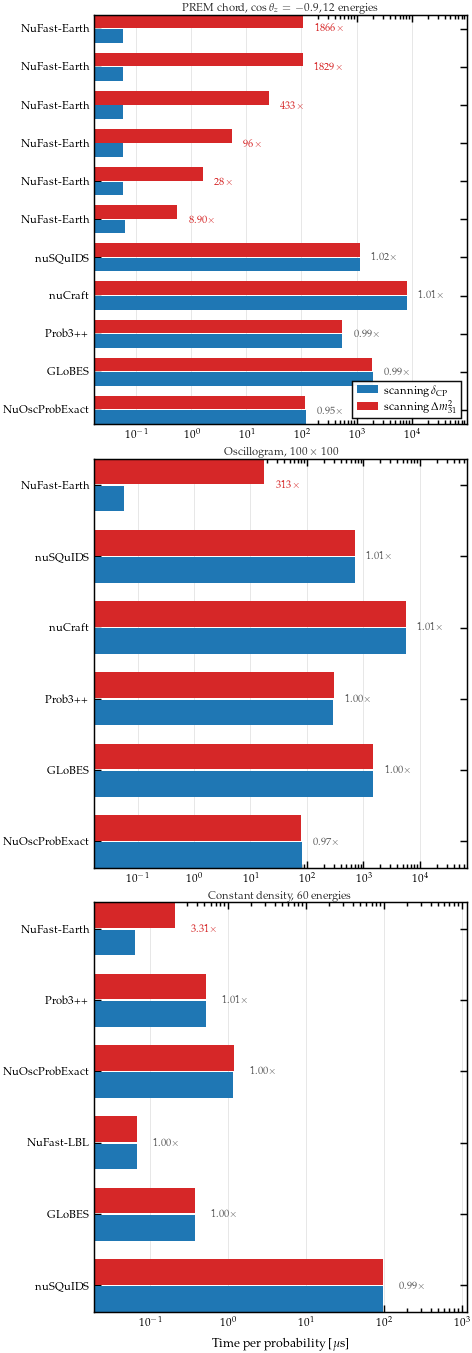

largest parameter sensitivity: NuFast-Earth, 1866x


In [15]:
# Paired at the same code, grid and knob: the two cells differ only in
# which parameter moves inside the timed region.
with open(os.path.join('..', 'tests', 'bench',
                       'scan_sensitivity.json')) as handle:
    sens = json.load(handle)

GRID_TITLE = {"CHORD/12x1": r"PREM chord, $\cos\theta_z=-0.9$, 12 energies",
              "OSC/100x100": r"Oscillogram, $100\times100$",
              "CONST/60E": r"Constant density, 60 energies"}
ORDER = ["CHORD/12x1", "OSC/100x100", "CONST/60E"]
grids = [g for g in ORDER if sens["grids"].get(g)]

fig, axes = plt.subplots(len(grids), 1, figsize=(COLW, 0.95*COLW*len(grids)),
                         squeeze=False)
for ax, grid in zip(axes[:, 0], grids):
    rows = sens["grids"][grid]
    y = np.arange(len(rows))
    # Sorted by ratio, so the code the effect belongs to is the top row and
    # the reader does not have to hunt for it.
    ax.barh(y + 0.19, [r["dcp_us"] for r in rows], height=0.36,
            color="C0", label=r"scanning $\delta_{\rm CP}$")
    ax.barh(y - 0.19, [r["dmsq31_us"] for r in rows], height=0.36,
            color="C3", label=r"scanning $\Delta m^2_{31}$")
    for i, r in enumerate(rows):
        # The ratio is the whole point, so it is written on the figure
        # rather than left to be read off a log axis.
        ax.text(max(r["dcp_us"], r["dmsq31_us"])*1.6, i,
                (r"$%.0f\times$" % r["ratio"]) if r["ratio"] >= 10
                else (r"$%.2f\times$" % r["ratio"]),
                va="center", fontsize=5.0,
                color="C3" if r["ratio"] > 2 else "0.35")
    ax.set_yticks(y)
    ax.set_yticklabels([r["code"] for r in rows], fontsize=5.4)
    # Sorted by ratio, and inverted so that the largest is the TOP row:
    # barh puts index zero at the bottom, which buried the one code the
    # figure exists to show under the five that show nothing.
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlim(min(r["dcp_us"] for r in rows)*0.30,
                max(r["dmsq31_us"] for r in rows)*12)
    ax.tick_params(axis="x", labelsize=5.4)
    # As a title rather than inside the axes, where it landed on top of the
    # ratio of whichever code sat in the corner.
    ax.set_title(GRID_TITLE.get(grid, grid), fontsize=5.4, color="0.2",
                 pad=2.0)
    ax.grid(axis="x", lw=0.4, alpha=0.35)
    ax.set_axisbelow(True)

axes[-1, 0].set_xlabel(r"Time per probability [$\mu$s]", fontsize=6.0)
leg = axes[0, 0].legend(loc="lower right", fontsize=5.4, framealpha=0.95)
leg.get_frame().set_linewidth(0.7)
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "scan_sensitivity.pdf"))
plt.show()

worst = max((r for g in sens["grids"].values() for r in g),
            key=lambda r: r["ratio"])
print("largest parameter sensitivity: %s, %.0fx" % (worst["code"],
                                                    worst["ratio"]))

## Performance

Three ways of evaluating the same scan: one point at a time, the whole stack
in one call, and the whole stack through the compiled kernel. The cost per
point is what a parameter scan actually pays.

       N loop [us/pt] array [us/pt] numba [us/pt]
       1       18.798       68.610       41.236
       3       12.624       30.218       13.577
      10       11.245       16.821        4.070
      30       10.885        5.125        1.419
     100       10.671        1.790        0.608
     300       11.300        0.788        0.256
    1000       11.549        0.425        0.109
    3000       11.743        0.276        0.068
   10000       11.938        0.237        0.042
   30000       11.543        0.331        0.041

at the largest N: array is 35x the loop, numba a further 8.0x


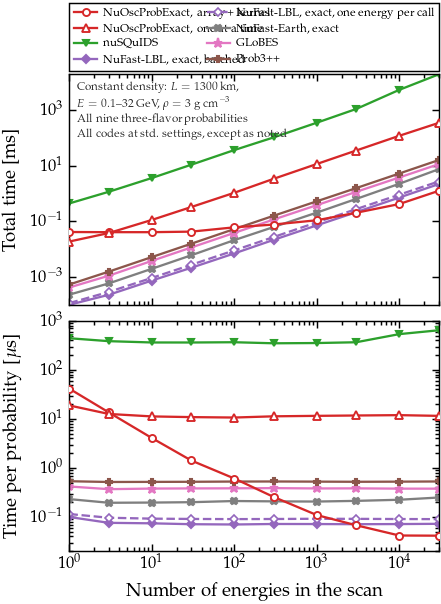

In [16]:
# Every timing in this notebook, and every timing quoted in the paper,
# was measured on one laptop:
#
#     Intel Core i5-1334U, 10 cores / 12 threads, up to 4.6 GHz
#     16 GB RAM
#     Ubuntu 24.04.4 LTS, kernel 7.0.0-28-generic
#     Python 3.12.7, numpy 1.26.4, numba 0.60.0, gcc 13.3
#
# Absolute times mean little without that, and would be perhaps a factor
# of two different on a workstation.  The ratios between routes, which is
# what these cells are actually about, are far more stable than the
# absolute numbers and are what the text quotes.
import time
import fastkernels


def best_of(func, repeat=5):
    # The minimum, not the mean: timing noise is one-sided, so the fastest
    # run is the one least polluted by whatever else the machine was doing.
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        func()
        best = min(best, time.perf_counter()-t0)
    return best


L = 1300.0*KM
sizes = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000, 30000]
rows = []
for n in sizes:
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, np.logspace(-1.0, 1.5, n)*GEV, gd.VCC_EARTH_CRUST)
    fastkernels.USE_NUMBA = False
    t_loop = best_of(lambda: [oscprob3nu.probabilities_3nu(h, L)
                              for h in Hs], repeat=3)
    t_array = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    if fastkernels.HAVE_NUMBA:
        fastkernels.USE_NUMBA = True
        oscprob3nu.probabilities_3nu(Hs, L)          # warm the compiler
        t_numba = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
        fastkernels.USE_NUMBA = False
    else:
        t_numba = np.nan
    rows.append((n, t_loop, t_array, t_numba))
rows = np.array(rows)
fastkernels.USE_NUMBA = fastkernels.HAVE_NUMBA

print("%8s %12s %12s %12s" % ("N", "loop [us/pt]", "array [us/pt]",
                              "numba [us/pt]"))
for n, tl, ta, tn in rows:
    print("%8d %12.3f %12.3f %12.3f"
          % (n, tl/n*1e6, ta/n*1e6, tn/n*1e6))
print("\nat the largest N: array is %.0fx the loop, numba a further %.1fx"
      % (rows[-1, 1]/rows[-1, 2], rows[-1, 2]/rows[-1, 3]))

with open(os.path.join('..', 'tests', 'timing_other_codes.json')) as handle:
    other = json.load(handle)

fig, (axt, ax) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.30), sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.07})

# Two of the three routes through this library: the compiled kernel, which
# is what an installation gets, and one point at a time, which is what the
# batching is worth against.  The plain array path lies between them and is
# left out to keep the legend readable.  Marker and colour match the two
# Earth planes, so a reader tracks one code across three figures.
for col, style, size, lab in (
        (3, "-o", 3.4, "NuOscProbExact, array + kernel"),
        (1, "-^", 3.6, "NuOscProbExact, one at a time")):
    if col == 3 and not fastkernels.HAVE_NUMBA:
        continue
    kw = dict(ms=size, color="C3", mfc="white", mew=0.9, zorder=5)
    axt.loglog(rows[:, 0], rows[:, col]*1e3, style, label=lab, **kw)
    ax.loglog(rows[:, 0], rows[:, col]/rows[:, 0]*1e6, style, **kw)

# The external codes.  GLoBES and Prob3++ take one energy per call, so
# their cost per probability is flat in N, and that flatness is what the
# lower panel is for.  NuFast-LBL is NOT among them: it has taken a vector
# of energies since v2.0.0, and the earlier version of this figure timed it
# one energy at a time and then said in this comment that it could not do
# otherwise.  Both curves are drawn now -- the batched entry point and the
# same code called in a loop -- so what batching is worth to it is measured
# here rather than asserted.  nuSQuIDS has a multiple-energy mode and still
# does not fall, because what it amortises is the solver setup and not the
# integration.
for key, style, col, size, lab in (
        ("nuSQuIDS", "-v", "C2", 2.6, "nuSQuIDS"),
        ("NuFast-LBL", "-D", "C4", 2.4,
         r"NuFast-LBL, exact, batched"),
        ("NuFast-LBL (looped)", "--D", "C4", 2.4,
         r"NuFast-LBL, exact, one energy per call"),
        ("NuFast-Earth", "-X", "C7", 3.0, "NuFast-Earth, exact"),
        ("GLoBES", "-*", "C6", 4.4, "GLoBES"),
        ("Prob3++", "-P", "C5", 3.2, "Prob3++")):
    if key not in other["series"]:
        continue
    n = np.array(other["series"][key]["sizes"], dtype=float)
    t = np.array(other["series"][key]["seconds"])
    kw = dict(ms=size, color=col)
    if key.endswith("(looped)"):
        kw.update(mfc="white", mew=0.8)
    axt.loglog(n, t*1e3, style, label=lab, **kw)
    ax.loglog(n, t/n*1e6, style, **kw)

axt.set_ylabel("Total time [ms]")
axt.text(0.02, 0.97, "Constant density:  " + r"$L = 1300$ km," + "\n"
         r"$E = 0.1$--$32$ GeV,  $\rho = 3$ g cm$^{-3}$" + "\n"
         "All nine three-flavor probabilities" + "\n"
         "All codes at std.\\ settings, except as noted",
         transform=axt.transAxes, ha="left", va="top", fontsize=5.6,
         color="0.2", linespacing=1.4)
# `mode="expand"` with the anchor spanning the axes makes the legend box
# exactly as wide as the panels it sits above.
leg = axt.legend(loc="lower left", bbox_to_anchor=(0.0, 1.015, 1.0, 0.1),
                 mode="expand", ncol=2, fontsize=5.6, borderaxespad=0.0,
                 columnspacing=1.2, handlelength=2.0)
leg.get_frame().set_linewidth(0.7)
ax.set_xlim(rows[0, 0], rows[-1, 0])
ax.set_xlabel("Number of energies in the scan")
ax.set_ylabel(r"Time per probability [$\mu$s]")
ax.set_ylim(2.0e-2, 1.0e3)
fig.savefig(os.path.join(FIGDIR, "performance.pdf"), bbox_inches="tight")
plt.show()

## Comparison to the alternatives

Three ways of getting the same number at $L = 1300$ km, in constant matter:
the closed form here; **nuSQuIDS**, an independently written C++ code that
integrates the density matrix numerically; and the standard second-order
expansion in $\alpha = \Delta m^2_{21}/\Delta m^2_{31}$ and $s_{13}$ used
throughout long-baseline physics (Cervera *et al.*; Akhmedov *et al.*).

The nuSQuIDS curve is read from a frozen JSON file, generated separately by
`tests/nusquids_scan.py`, so this notebook does not need nuSQuIDS installed.

max |NuOscProbExact           - reference| = 1.1e-15
max |nuSQuIDS                 - reference| = 8.9e-08
max |NuFast-LBL               - reference| = 2.3e-08
max |GLoBES                   - reference| = 2.8e-08
max |Prob3++                  - reference| = 2.8e-05
max |$\alpha$--$s_{13}$ expansion - reference| = 6.6e-03


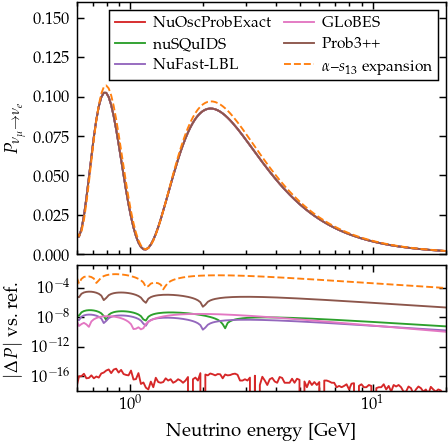

In [17]:
# P(nu_mu -> nu_e) to second order in alpha and s13, constant density:
# Akhmedov, Johansson, Lindner, Ohlsson & Schwetz, hep-ph/0402175, Eq. (32).
# Evaluated directly as the analytic expression it is -- NuOscProbExact is
# not involved, and could not be: it returns the exact answer.
def p_mue_expansion(E_ev, L, s12, s13, s23, dcp, dm21, dm31, vcc):
    c12 = np.sqrt(1.0 - s12**2.0)
    c23 = np.sqrt(1.0 - s23**2.0)
    alpha = dm21/dm31
    Delta = dm31*L/(4.0*E_ev)
    A = 2.0*vcc*E_ev/dm31
    om = 1.0 - A
    return (4.0*s13**2.0*s23**2.0*np.sin(om*Delta)**2.0/om**2.0
            + alpha*8.0*s13*s12*c12*s23*c23*np.cos(Delta + dcp)
            * np.sin(A*Delta)/A*np.sin(om*Delta)/om
            + alpha**2.0*4.0*s12**2.0*c12**2.0*c23**2.0
            * np.sin(A*Delta)**2.0/A**2.0)


with open(os.path.join('..', 'tests', 'nusquids_scan.json')) as handle:
    ref = json.load(handle)
with open(os.path.join('..', 'tests', 'nufast_scan.json')) as handle:
    nuf = json.load(handle)

E_gev = np.array(ref['energy_gev'])
E = E_gev*GEV
L_km = ref['baseline_km']
rho = ref['density_g_cm3']
L = L_km*KM
vcc = earth.matter_potential(rho)

# Every curve is refereed by the same 50-digit matrix exponential as the
# speed-accuracy plane, so that this library is not its own referee here
# either.  The reference, and the GLoBES and Prob3++ scans, are frozen in
# tests/const_density_scan.json.
with open(os.path.join('..', 'tests', 'const_density_scan.json')) as handle:
    cd = json.load(handle)

reference = np.array(cd['probability_reference'])
exact = oscprob3nu.probabilities_3nu(
    hamiltonians3nu.hamiltonian_3nu_matter(H_VAC_3NU, E, vcc), L)[:, 3]
curves = [
    ("NuOscProbExact", "-", "C3", exact),
    ("nuSQuIDS", "-", "C2", np.array(ref['probability'])),
    ("NuFast-LBL", "-", "C4", np.array(nuf['probability_N_Newton_2'])),
    ("GLoBES", "-", "C6", np.array(cd['probability_globes'])),
    ("Prob3++", "-", "C5", np.array(cd['probability_prob3pp'])),
    (r"$\alpha$--$s_{13}$ expansion", "--", "C1",
     p_mue_expansion(E, L, gd.S12_NO_BF, gd.S13_NO_BF, gd.S23_NO_BF,
                     gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, vcc)),
]

for name, _, _, values in curves:
    print("max |%-24s - reference| = %.1e"
          % (name, np.abs(values-reference).max()))

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.06), sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.2], "hspace": 0.06})

for name, dash, colour, values in curves:
    ax.semilogx(E_gev, values, dash, color=colour, lw=0.9, label=name)
    axr.loglog(E_gev, np.abs(values-reference), dash, color=colour, lw=0.9)
ax.set_ylabel(r"$P_{\nu_\mu \to \nu_e}$")
ax.set_ylim(0.0, 0.16)
framed(ax, loc="upper right", ncol=2)

axr.set_ylabel(r"$|\Delta P|$ vs.\ ref.")
axr.set_xlabel("Neutrino energy [GeV]")
axr.set_xlim(E_gev[0], E_gev[-1])
axr.set_ylim(1.0e-18, 1.0e-1)
axr.set_yticks([1.0e-16, 1.0e-12, 1.0e-8, 1.0e-4])
fig.savefig(os.path.join(FIGDIR, "exact_vs_approximations.pdf"))
plt.show()

## Two flavors, four scenarios

The two-neutrino counterpart of the three-flavor figure, driven by
$\Delta m^2_{31}$ and $\theta_{23}$, over a slightly wider energy range.

Note the first argument: the builders take $\sin\theta$, not $\theta$.

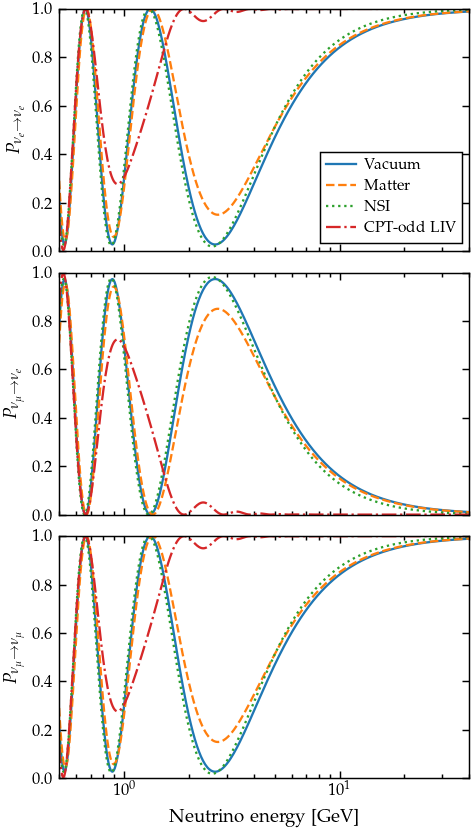

In [18]:
E_gev = np.logspace(np.log10(0.5), np.log10(40.0), 400)
E = E_gev*GEV
L = 1300.0*KM

H2_VAC = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    gd.S23_NO_BF, gd.D31_NO_BF)

p2 = {
    "Vacuum": oscprob2nu.probabilities_2nu(
        np.asarray(H2_VAC)/E[:, None, None], L),
    "Matter": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_matter(
            H2_VAC, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_nsi(
            H2_VAC, E, gd.VCC_EARTH_CRUST, gd.EPS_2), L),
    "CPT-odd LIV": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_liv(
            H2_VAC, E, gd.SXI12, gd.B1, gd.B3, gd.LAMBDA), L),
}

panels2 = [(0, r"$P_{\nu_e \to \nu_e}$"),
           (2, r"$P_{\nu_\mu \to \nu_e}$"),
           (3, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_STACK, sharex=True)
for ax, (k, ylabel) in zip(axes, panels2):
    for (name, prob), ls in zip(p2.items(), STYLES):
        ax.semilogx(E_gev, prob[:, k], ls, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
    ax.set_ylim(0.0, 1.0)
framed(axes[0], loc="lower right")
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "prob_2nu_vs_energy_compare.pdf"))
plt.show()

---

**Previous:** [Performance](09_performance.ipynb)  
**Next:** [Exact versus the textbook approximations](11_exact_vs_approximations.ipynb) --- where the familiar formulas break, and by how much  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)